#Dependencies

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%%capture
# INSTRUCTIONS:
# 1. Run this cell.
# 2. After it finishes, go to the menu and click "Runtime" -> "Restart session".
# 3. run this cell again
try:
    import optuna
    print("Libraries are already installed. Skipping to Part B.")
    _libraries_installed = True
except (ImportError, ValueError): # Catch the incompatibility error on restart
    print("Installing required libraries for hyperparameter tuning...")
    # Using -q for a quieter installation
    !pip install lightgbm==4.1.0 optuna==3.4.0 shap==0.42.1 "numpy<2.0" -q
    print("\nLibraries installed successfully. Please RESTART the runtime now and run this cell again.")
    _libraries_installed = False

!pip install "numpy<2.0" "shap==0.45.0"

In [ ]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import LeaveOneGroupOut
import joblib
import os
import matplotlib.pyplot as plt
import seaborn as sns
import gc
import shap
from datetime import datetime
import json

# Load Training data

In [ ]:
file_path = '/content/drive/MyDrive/Flux_upscaling/v2_model_training_02Oct25.csv'
print(f"\nLoading data from: {file_path}")

try:
    # Load the training data from the specified CSV file.
    # We use low_memory=False to ensure correct data type inference for all columns.
    df_train = pd.read_csv(file_path, low_memory=False)
    print("Data loaded successfully.")

    # --- 5. Initial Data Inspection ---
    # Display the first 5 rows to verify the data has loaded correctly.
    print("\n--- First 5 Rows of the DataFrame ---")
    print(df_train.head())

    # Display a concise summary of the DataFrame, including data types and non-null counts.
    print("\n--- DataFrame Info ---")
    df_train.info()

except FileNotFoundError:
    print(f"\n--- ERROR ---")
    print(f"File not found at the specified path: {file_path}")
    print("Please make sure the file path is correct and the file exists in your Google Drive.")

except Exception as e:
    print(f"\n--- An unexpected error occurred ---")
    print(e)


Loading data from: /content/drive/MyDrive/Flux_upscaling/v2_model_training_02Oct25.csv
Data loaded successfully.

--- First 5 Rows of the DataFrame ---
                                           site_name  \
0                                         Skyttorp 2   
1                                  Wolf_creek_forest   
2  Alberta - Western Peatland - LaBiche River,Bla...   
3                             Elgeeii forest station   
4                                           Faejemyr   

                                      site_reference   latitude   longitude  \
0                            Skyttorp 2_SE-Sk2_tower  60.129667   17.840056   
1                     Wolf_creek_forest_CA-WCF_tower  60.596886 -134.952833   
2  Alberta - Western Peatland - LaBiche River,Bla...  54.953840 -112.466980   
3                Elgeeii forest station_RU-Ege_tower  60.015516  133.824012   
4                              Faejemyr_SE-Faj_tower  56.265500   13.553500   

  flux_method country  land_cover_e

# --- 1. Load and Merge Satellite Embedding (SE) Data ---

In [ ]:
se_file_path = '/content/drive/MyDrive/Flux_upscaling/satellite_embeddings.csv'
print(f"Loading satellite embedding data from: {se_file_path}")

try:
    df_se = pd.read_csv(se_file_path)
    print("Satellite embedding data loaded successfully.")

    # Merge the SE data into our main training dataframe.
    # We assume the join keys are 'site_name' and 'year'.
    # Please verify these are the correct columns to link the two datasets.
    print("\nMerging dataframes...")
    df_train = pd.merge(df_train, df_se, on=['site_name', 'year'], how='left')
    print("Merge complete.")

    # Clean up the SE dataframe to save memory
    del df_se
    gc.collect()

except FileNotFoundError:
    print(f"\n--- ERROR ---")
    print(f"Satellite embedding file not found at: {se_file_path}")
    print("Please update the path. If you don't have this file yet, this block cannot be completed.")
    # Stop execution if the file isn't found
    raise

except Exception as e:
    print(f"\n--- An unexpected error occurred during SE data loading/merging ---")
    print(e)
    raise

# --- 2. Handle Missing Satellite Embedding and Target Values ---
print("\nHandling missing values...")

# Define the SE feature columns to check for missing data
se_features = [f'SE_{i}' for i in range(64)]

# Drop rows where the satellite embedding data is missing (e.g., for high-latitude sites)
initial_rows = len(df_train)
df_train.dropna(subset=se_features, how='any', inplace=True)
rows_after_se_drop = len(df_train)
print(f"Dropped {initial_rows - rows_after_se_drop} rows due to missing satellite embeddings.")

# We can only train on rows where we have at least one valid target measurement.
# This also significantly reduces memory usage.
target_cols = ['gpp', 'reco', 'nee', 'ch4_flux_total']
initial_rows = len(df_train)
df_train.dropna(subset=target_cols, how='all', inplace=True)
rows_after_target_drop = len(df_train)
print(f"Dropped {initial_rows - rows_after_target_drop} rows due to missing target values.")
print(f"Final DataFrame shape for training: {df_train.shape}")


# --- 3. Engineer Core & Time Features ---
print("\nEngineering core & time features...")
# FIX: Calculate mean temperature from min and max temperature columns
df_train['tmean_C'] = (df_train['tmmn'] + df_train['tmmx']) / 2
print("tmean_C created from tmmn and tmmx.")

# Sinusoidal encoding for month
df_train['month_sin'] = np.sin(2 * np.pi * df_train['month']/12)
df_train['month_cos'] = np.cos(2 * np.pi * df_train['month']/12)
print("month_sin and month_cos created.")


# --- 4. Engineer Location Features (Sinusoidal Encoding) ---
print("\nEngineering location features...")
df_train['latitude_sin'] = np.sin(np.deg2rad(df_train['latitude']))
df_train['latitude_cos'] = np.cos(np.deg2rad(df_train['latitude']))
df_train['longitude_sin'] = np.sin(np.deg2rad(df_train['longitude']))
df_train['longitude_cos'] = np.cos(np.deg2rad(df_train['longitude']))
print("latitude_sin/cos and longitude_sin/cos created.")


# --- 5. Define Final Feature and Target Lists ---
print("\nDefining feature and target lists...")

# Base predictors from our plan
predictor_vars = [
    'EVI', 'NDVI', 'NDWI', 'lai', 'fpar', 'sur_refl_b01', 'sur_refl_b02',
    'sur_refl_b03', 'sur_refl_b07', 'Percent_Tree_Cover', 'Percent_NonTree_Vegetation',
    'Percent_NonVegetated', 'tmean_C', 'pdsi', 'srad', 'vap', 'vs', 'co2_cont',
    'bdod_0_100cm', 'cec_0_100cm', 'cfvo_0_100cm', 'clay_0_100cm', 'nitrogen_0_100cm',
    'ocd_0_100cm', 'phh2o_0_100cm', 'sand_0_100cm', 'silt_0_100cm', 'soc_0_100cm',
    'ALT', 'sm_surface', 'sm_rootzone', 'snow_cover', 'snow_depth'
]

# Engineered time & location features
engineered_features = [
    'month_sin', 'month_cos', 'latitude_sin', 'latitude_cos',
    'longitude_sin', 'longitude_cos'
]

# Combine all features into the final list
final_features = predictor_vars + engineered_features + se_features

print(f"Total number of features: {len(final_features)}")
print("Feature and target lists defined.")

# --- 6. Final DataFrame Inspection ---
print("\n--- Final DataFrame State ---")
# Display a sample of the dataframe with a few key new columns
print(df_train[['site_name', 'year', 'month', 'tmean_C', 'gpp'] + se_features[:2]].head())
print("\n--- Final DataFrame Info ---")
df_train.info(verbose=False, memory_usage='deep')

# --- 7. Clean up Memory ---
# Drop original columns that are no longer needed to save memory
df_train.drop(columns=['tmmn', 'tmmx'], inplace=True, errors='ignore')
gc.collect()
print("\nPreprocessing complete and memory cleaned.")



Loading satellite embedding data from: /content/drive/MyDrive/Flux_upscaling/satellite_embeddings.csv
Satellite embedding data loaded successfully.

Merging dataframes...
Merge complete.

Handling missing values...
Dropped 1416 rows due to missing satellite embeddings.
Dropped 44373 rows due to missing target values.
Final DataFrame shape for training: (10942, 130)

Engineering core & time features...
tmean_C created from tmmn and tmmx.
month_sin and month_cos created.

Engineering location features...
latitude_sin/cos and longitude_sin/cos created.

Defining feature and target lists...
Total number of features: 103
Feature and target lists defined.

--- Final DataFrame State ---
                                            site_name  year  month  tmean_C  \
6                                       Fyodorovskoye  2000      3    -3.35   
23        Saskatchewan - Western Boreal, Mature Aspen  2000      3    -4.45   
46                                      Fyodorovskoye  2000      4     8.8

# EDA

--- 1. Visualizing Target Variable Distributions ---


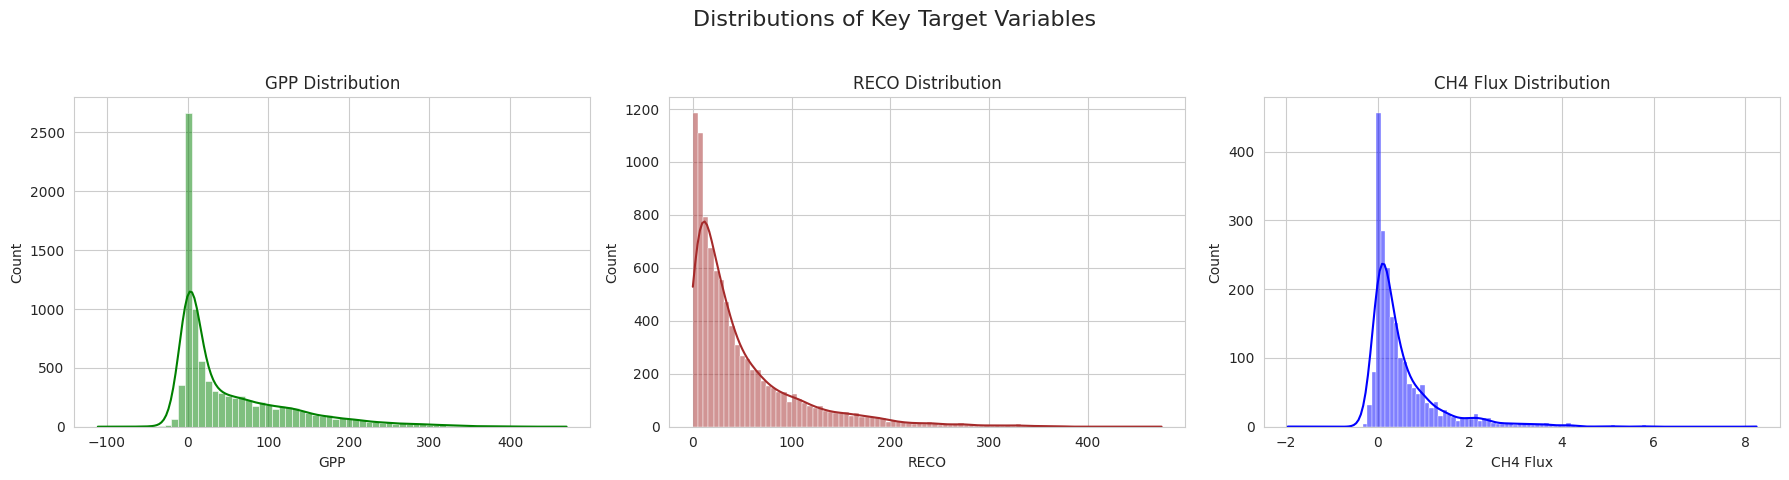


--- 2. Analyzing Missing Values in Predictor Features ---
Features with missing values (These will be handled automatically by LightGBM):
                                               feature  missing_count  \
ALT                                                ALT           4141   
sur_refl_b02                              sur_refl_b02           3927   
NDVI                                              NDVI           3927   
sur_refl_b07                              sur_refl_b07           3927   
sur_refl_b03                              sur_refl_b03           3927   
EVI                                                EVI           3927   
sur_refl_b01                              sur_refl_b01           3927   
NDWI                                              NDWI           3927   
nitrogen_0_100cm                      nitrogen_0_100cm           2808   
soc_0_100cm                                soc_0_100cm           2808   
silt_0_100cm                              silt_0_100cm    

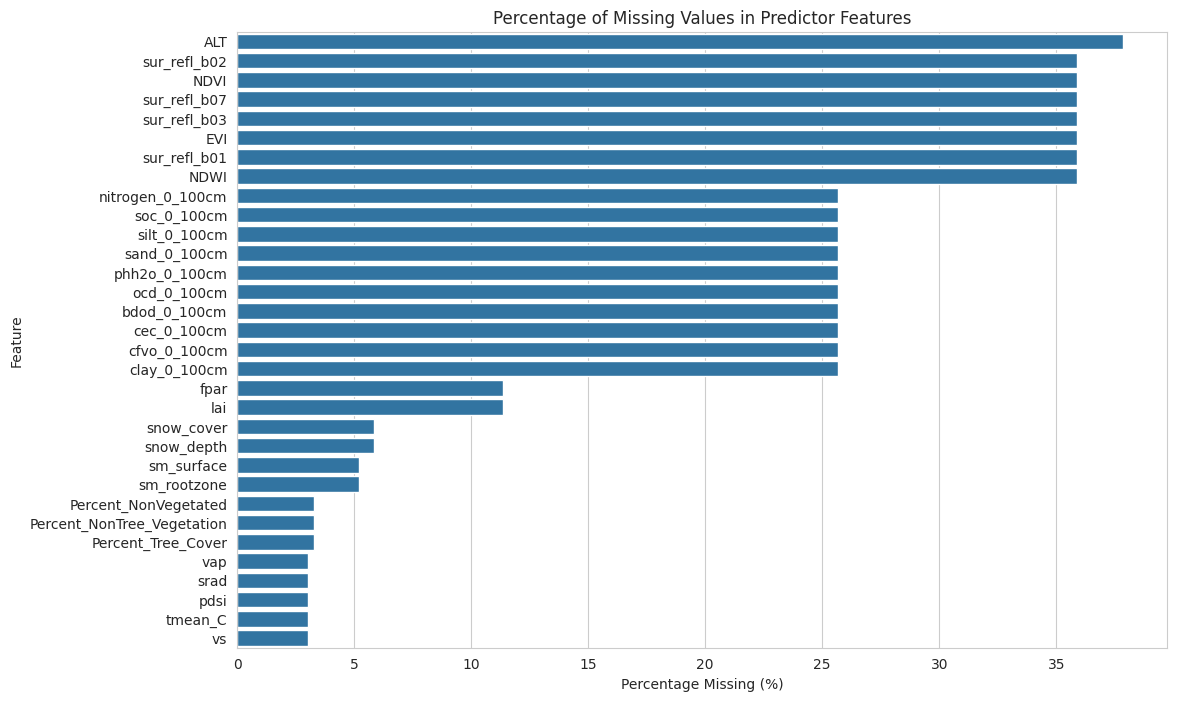


--- 3. Visualizing Top Feature Correlations ---


/tmp/ipython-input-37636683.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_20_gpp.values, y=top_20_gpp.index, ax=axes[0], palette='viridis')
/tmp/ipython-input-37636683.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_20_reco.values, y=top_20_reco.index, ax=axes[1], palette='plasma')


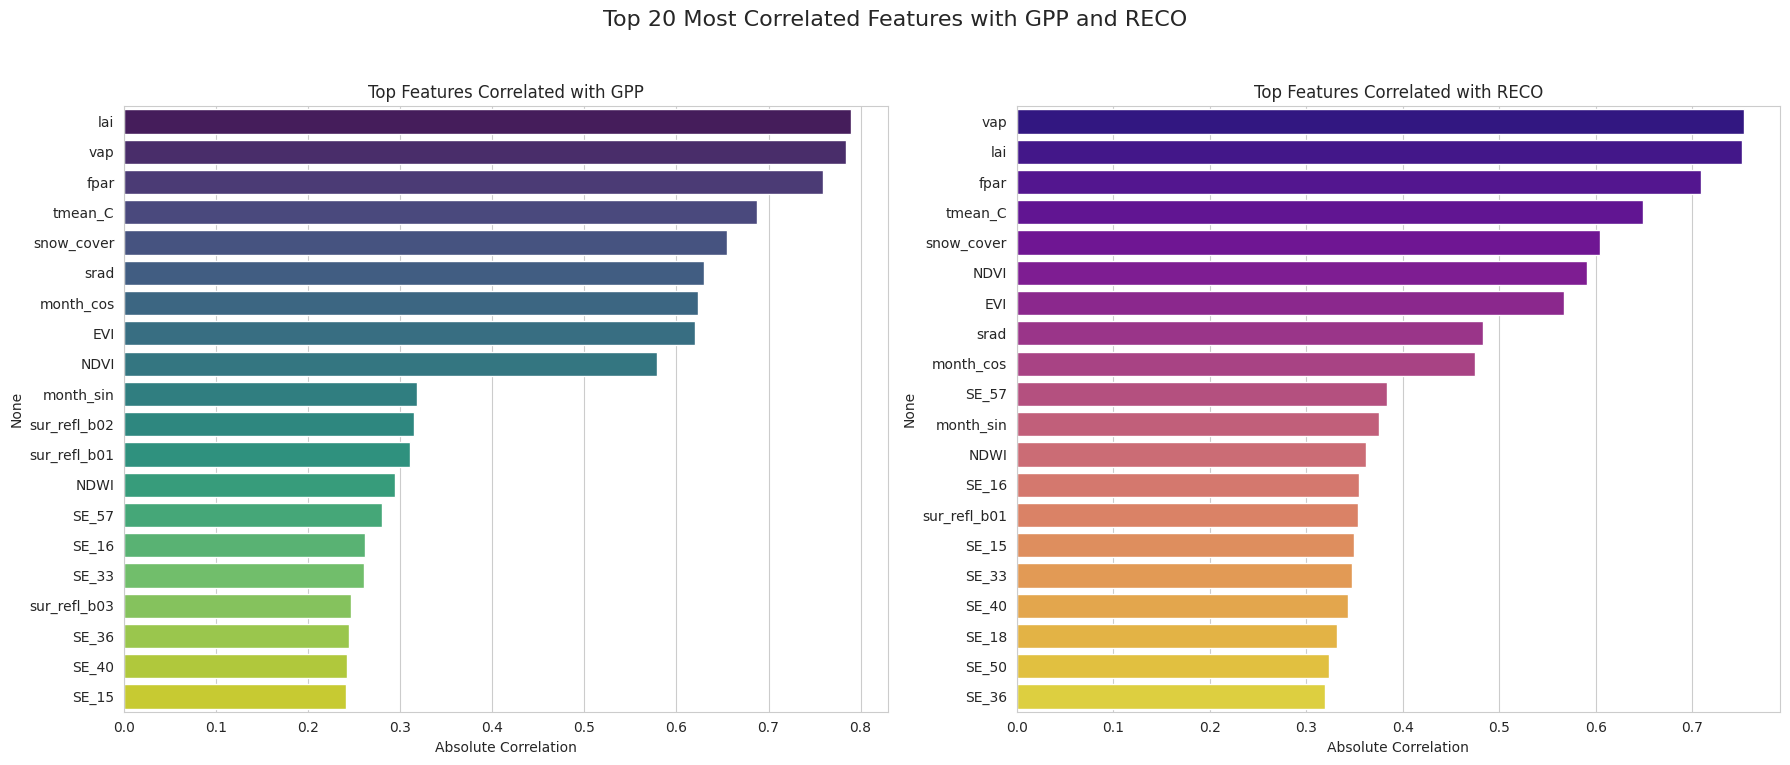


Visualization and analysis complete. We will not impute missing values.


In [ ]:
# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 5)

# --- 1. Visualize Target Variable Distributions ---
print("--- 1. Visualizing Target Variable Distributions ---")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Distributions of Key Target Variables', fontsize=16)

# Plot GPP
sns.histplot(df_train['gpp'].dropna(), kde=True, ax=axes[0], color='green')
axes[0].set_title('GPP Distribution')
axes[0].set_xlabel('GPP')

# Plot RECO
sns.histplot(df_train['reco'].dropna(), kde=True, ax=axes[1], color='brown')
axes[1].set_title('RECO Distribution')
axes[1].set_xlabel('RECO')

# Plot CH4
sns.histplot(df_train['ch4_flux_total'].dropna(), kde=True, ax=axes[2], color='blue')
axes[2].set_title('CH4 Flux Distribution')
axes[2].set_xlabel('CH4 Flux')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


# --- 2. Analyze Missing Values in Predictor Features ---
print("\n--- 2. Analyzing Missing Values in Predictor Features ---")
missing_values = df_train[final_features].isnull().sum()
missing_percentage = (missing_values / len(df_train)) * 100
missing_df = pd.DataFrame({'feature': final_features, 'missing_count': missing_values, 'missing_percentage': missing_percentage})
missing_df = missing_df[missing_df['missing_count'] > 0].sort_values(by='missing_percentage', ascending=False)

if not missing_df.empty:
    print("Features with missing values (These will be handled automatically by LightGBM):")
    print(missing_df)

    plt.figure(figsize=(12, 8))
    sns.barplot(x='missing_percentage', y='feature', data=missing_df)
    plt.title('Percentage of Missing Values in Predictor Features')
    plt.xlabel('Percentage Missing (%)')
    plt.ylabel('Feature')
    plt.show()
else:
    print("No missing values found in any predictor features.")


# --- 3. Visualize Top Feature Correlations with GPP and RECO ---
print("\n--- 3. Visualizing Top Feature Correlations ---")

# Calculate correlations with GPP
correlations_gpp = df_train[final_features + ['gpp']].corr()['gpp'].abs().sort_values(ascending=False)
top_20_gpp = correlations_gpp[1:21] # Exclude self-correlation

# Calculate correlations with RECO
correlations_reco = df_train[final_features + ['reco']].corr()['reco'].abs().sort_values(ascending=False)
top_20_reco = correlations_reco[1:21]

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('Top 20 Most Correlated Features with GPP and RECO', fontsize=16)

# Plot for GPP
sns.barplot(x=top_20_gpp.values, y=top_20_gpp.index, ax=axes[0], palette='viridis')
axes[0].set_title('Top Features Correlated with GPP')
axes[0].set_xlabel('Absolute Correlation')

# Plot for RECO
sns.barplot(x=top_20_reco.values, y=top_20_reco.index, ax=axes[1], palette='plasma')
axes[1].set_title('Top Features Correlated with RECO')
axes[1].set_xlabel('Absolute Correlation')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print("\nVisualization and analysis complete. We will not impute missing values.")



# Baseline model

--- Starting Model Training and Evaluation ---

--- Training model for target: GPP ---
Training data shape: (9091, 103)
Performing 5-fold spatial cross-validation (grouped by 'site_name')...
  Fold 1 R2: 0.8338
  Fold 2 R2: 0.8055
  Fold 3 R2: 0.7935
  Fold 4 R2: 0.8595
  Fold 5 R2: 0.8219

Overall CV R2 for GPP: 0.8215
Overall CV RMSE for GPP: 30.9755

Training final model on all available data...
Final model training complete.

--- Training model for target: RECO ---
Training data shape: (9240, 103)
Performing 5-fold spatial cross-validation (grouped by 'site_name')...
  Fold 1 R2: 0.8193
  Fold 2 R2: 0.6779
  Fold 3 R2: 0.7530
  Fold 4 R2: 0.7457
  Fold 5 R2: 0.7278

Overall CV R2 for RECO: 0.7559
Overall CV RMSE for RECO: 28.2632

Training final model on all available data...
Final model training complete.

--- Evaluating NEE (reco_pred - gpp_pred) ---
Evaluation R2 for calculated NEE: 0.4026
Evaluation RMSE for calculated NEE: 24.1024


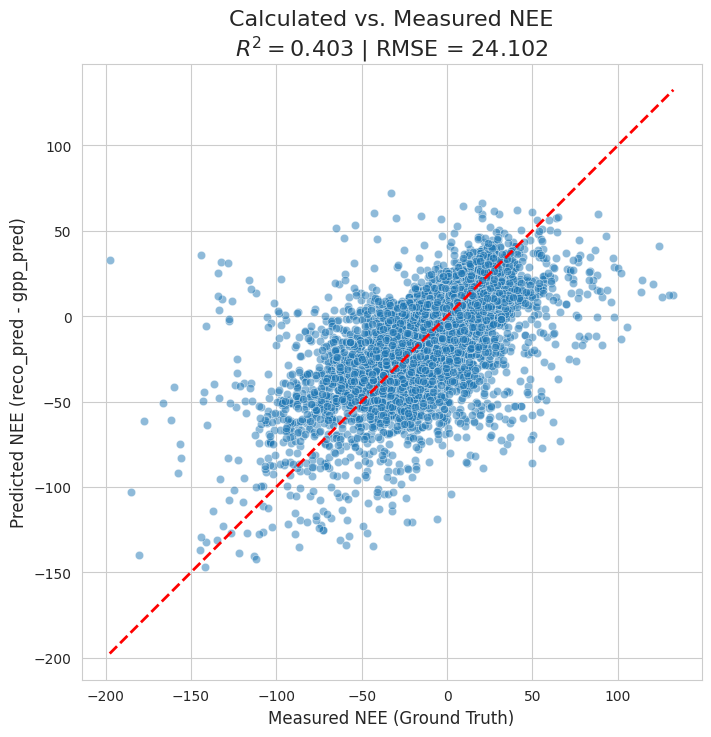


--- Training model for target: CH4_FLUX_TOTAL ---
Training data shape: (2159, 103)
Performing 5-fold spatial cross-validation (grouped by 'site_name')...
  Fold 1 R2: -0.0063
  Fold 2 R2: 0.1906
  Fold 3 R2: 0.2399
  Fold 4 R2: 0.2975
  Fold 5 R2: 0.0571

Overall CV R2 for CH4_FLUX_TOTAL: 0.1630
Overall CV RMSE for CH4_FLUX_TOTAL: 0.7196

Training final model on all available data...
Final model training complete.

--- All models have been trained and evaluated. ---
You can now use 'model_gpp', 'model_reco', and 'model_ch4' for inference.


In [ ]:
print("--- Starting Model Training and Evaluation ---")
# --- 1. Define Reusable Training Function ---
def train_and_evaluate_model(df, features, target_name, group_col='site_name', n_splits=5):
    """
    Trains and evaluates a Lightgbm model using spatial cross-validation.

    Args:
        df (pd.DataFrame): The training dataframe.
        features (list): List of feature column names.
        target_name (str): The name of the target variable column.
        group_col (str): The column to group by for spatial CV.
        n_splits (int): The number of cross-validation folds.

    Returns:
        np.array: Out-of-fold predictions for the entire dataset.
        lgb.LGBMRegressor: The final model trained on all data.
    """
    print(f"\n--- Training model for target: {target_name.upper()} ---")

    # Prepare data specific to this target (drop rows where target is NaN)
    model_df = df[df[target_name].notna()].copy()
    X = model_df[features]
    y = model_df[target_name]
    groups = model_df[group_col]

    print(f"Training data shape: {X.shape}")

    # Define model parameters
    params = {
        'objective': 'regression_l2', # L2 loss is Mean Squared Error
        'metric': 'rmse',
        'n_estimators': 1000,
        'learning_rate': 0.05,
        'feature_fraction': 0.8,
        'bagging_fraction': 0.8,
        'bagging_freq': 1,
        'lambda_l1': 0.1,
        'lambda_l2': 0.1,
        'num_leaves': 31,
        'verbose': -1,
        'n_jobs': -1,
        'seed': 42,
        'boosting_type': 'gbdt',
    }

    # Initialize cross-validation
    gkf = GroupKFold(n_splits=n_splits)
    oof_preds = np.zeros(len(y))

    # --- Cross-Validation Loop ---
    print(f"Performing {n_splits}-fold spatial cross-validation (grouped by '{group_col}')...")
    for fold, (train_idx, val_idx) in enumerate(gkf.split(X, y, groups)):
        X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
        X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]

        model = lgb.LGBMRegressor(**params)
        model.fit(X_train, y_train,
                  eval_set=[(X_val, y_val)],
                  eval_metric='rmse',
                  callbacks=[lgb.early_stopping(100, verbose=False)])

        fold_preds = model.predict(X_val)
        oof_preds[val_idx] = fold_preds

        fold_r2 = r2_score(y_val, fold_preds)
        print(f"  Fold {fold+1} R2: {fold_r2:.4f}")

    # --- Overall CV Performance ---
    overall_r2 = r2_score(y, oof_preds)
    overall_rmse = np.sqrt(mean_squared_error(y, oof_preds))
    print(f"\nOverall CV R2 for {target_name.upper()}: {overall_r2:.4f}")
    print(f"Overall CV RMSE for {target_name.upper()}: {overall_rmse:.4f}")

    # --- Final Model Training ---
    print("\nTraining final model on all available data...")
    final_model = lgb.LGBMRegressor(**params)
    final_model.fit(X, y)
    print("Final model training complete.")

    # Add OOF predictions back to the main dataframe for later use
    df[f'{target_name}_pred'] = np.nan
    df.loc[model_df.index, f'{target_name}_pred'] = oof_preds

    return final_model


# --- 2. Train GPP and RECO models ---
model_gpp = train_and_evaluate_model(df_train, final_features, 'gpp')
model_reco = train_and_evaluate_model(df_train, final_features, 'reco')
gc.collect()


# --- 3. Calculate and Evaluate NEE ---
print("\n--- Evaluating NEE (reco_pred - gpp_pred) ---")
# Select rows where we have both measured NEE and predictions for GPP and RECO
eval_nee_df = df_train.dropna(subset=['nee', 'gpp_pred', 'reco_pred'])

if not eval_nee_df.empty:
    # Calculate NEE from the out-of-fold predictions
    nee_predicted = eval_nee_df['reco_pred'] - eval_nee_df['gpp_pred']
    nee_measured = eval_nee_df['nee']

    # Evaluate the calculated NEE
    nee_r2 = r2_score(nee_measured, nee_predicted)
    nee_rmse = np.sqrt(mean_squared_error(nee_measured, nee_predicted))

    print(f"Evaluation R2 for calculated NEE: {nee_r2:.4f}")
    print(f"Evaluation RMSE for calculated NEE: {nee_rmse:.4f}")

    # --- ADDED: Visualize NEE Performance ---
    plt.figure(figsize=(8, 8))
    sns.scatterplot(x=nee_measured, y=nee_predicted, alpha=0.5)

    # Add a 1:1 line for reference
    min_val = min(nee_measured.min(), nee_predicted.min())
    max_val = max(nee_measured.max(), nee_predicted.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)

    plt.title(f'Calculated vs. Measured NEE\n$R^2 = {nee_r2:.3f}$ | RMSE = {nee_rmse:.3f}', fontsize=16)
    plt.xlabel('Measured NEE (Ground Truth)', fontsize=12)
    plt.ylabel('Predicted NEE (reco_pred - gpp_pred)', fontsize=12)
    plt.grid(True)
    plt.axis('equal')
    plt.show()

else:
    print("Could not evaluate NEE as there were no overlapping measured/predicted values.")


# --- 4. Train CH4 model ---
model_ch4 = train_and_evaluate_model(df_train, final_features, 'ch4_flux_total')
gc.collect()

print("\n--- All models have been trained and evaluated. ---")
print("You can now use 'model_gpp', 'model_reco', and 'model_ch4' for inference.")




--- Generating Diagnostic Plots for GPP Model ---


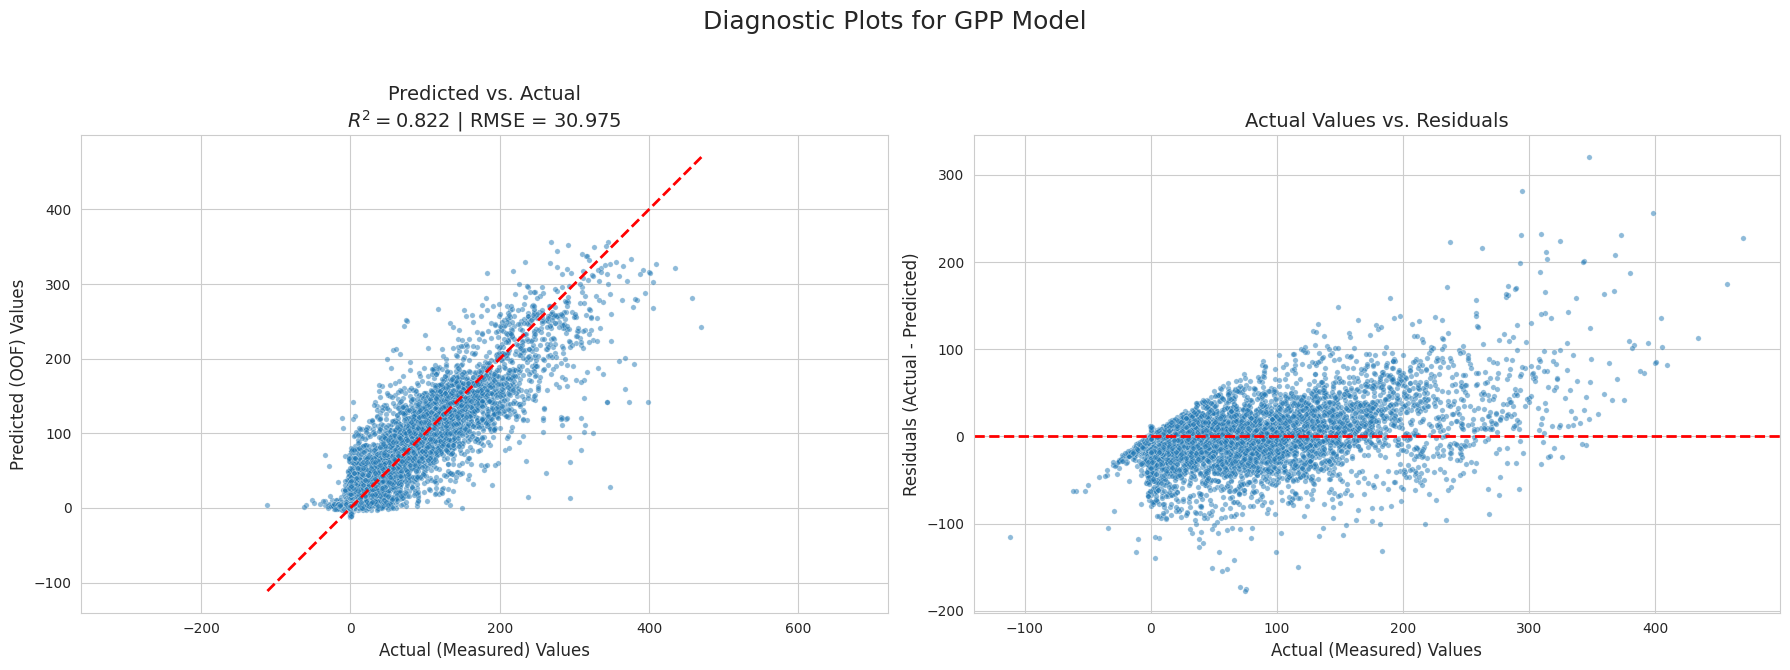


--- Generating Diagnostic Plots for RECO Model ---


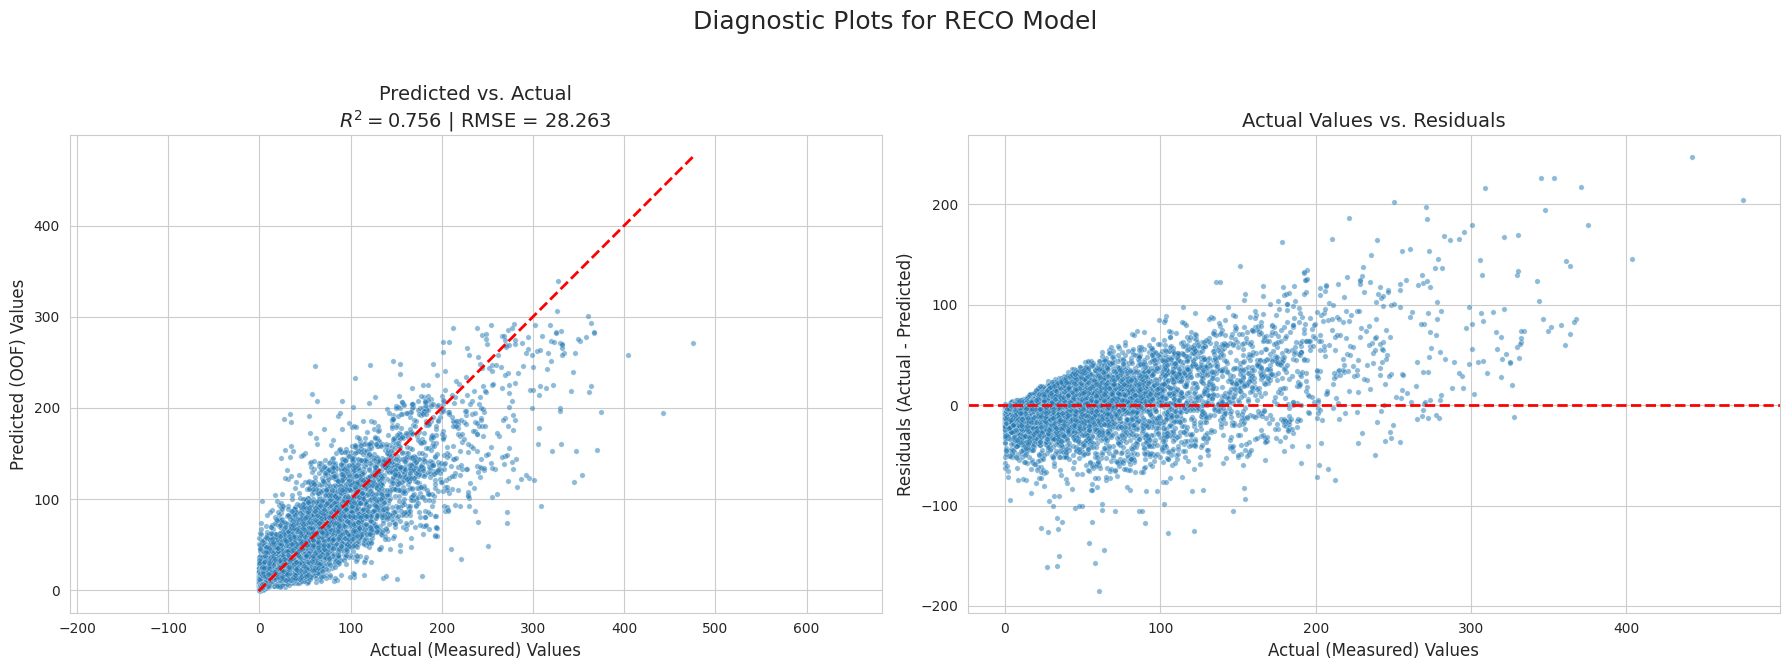


--- Calculating SHAP values for GPP Model ---
This may take a moment...
--- SHAP Summary Plot for GPP Model ---


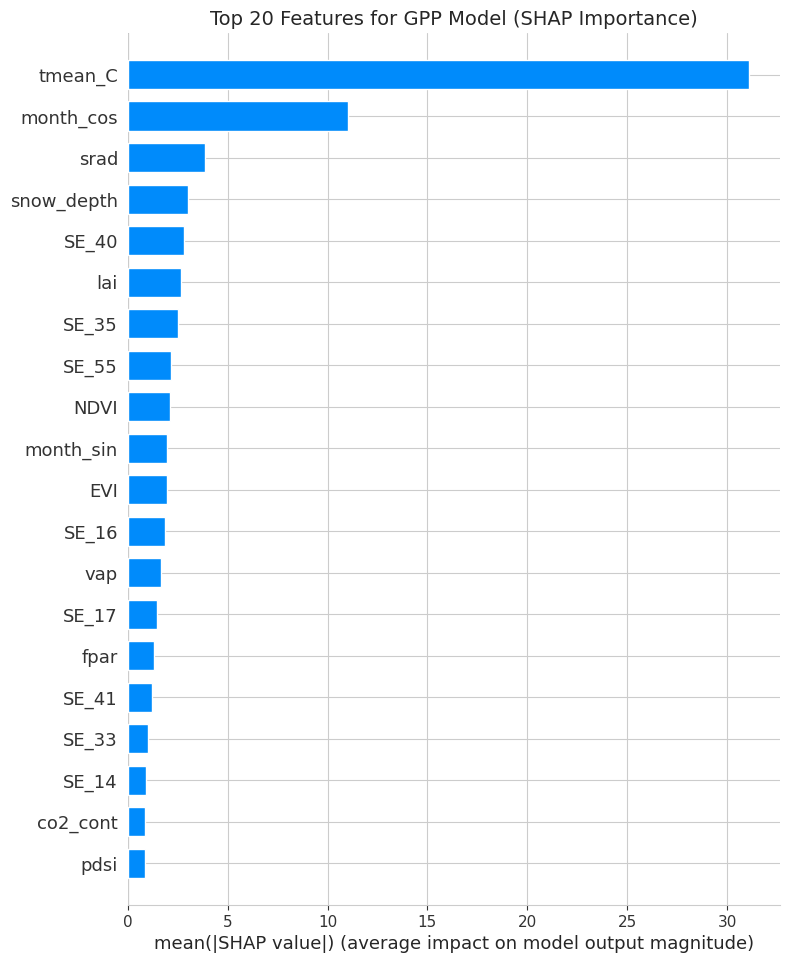


--- Calculating SHAP values for RECO Model ---
This may take a moment...
--- SHAP Summary Plot for RECO Model ---


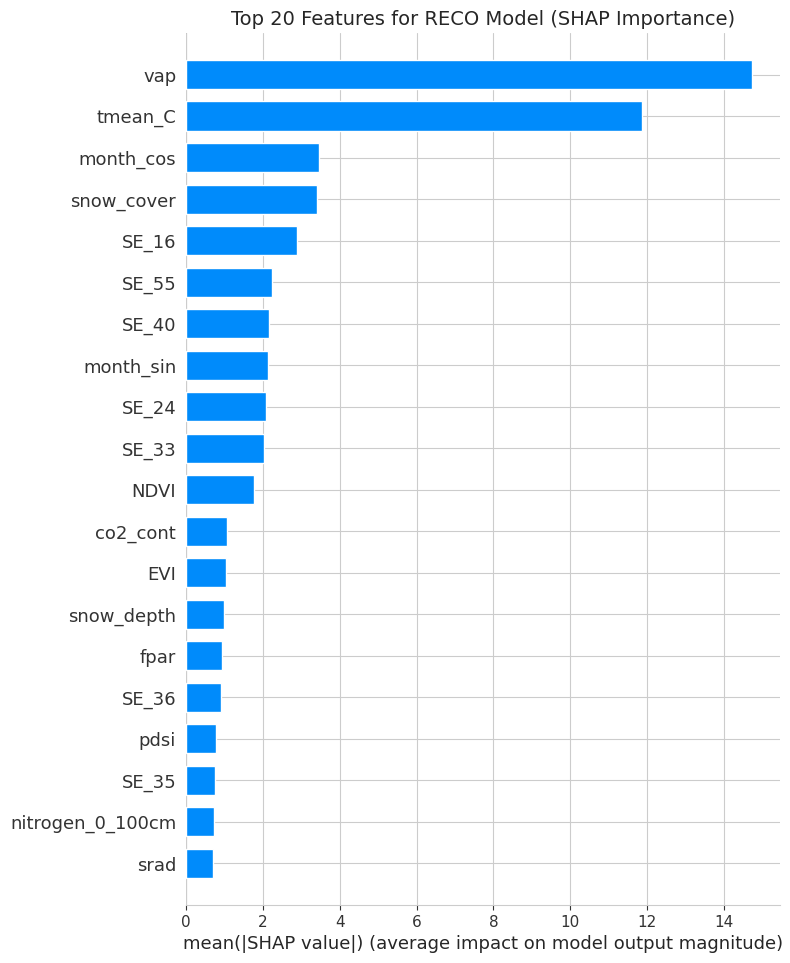


--- Comprehensive evaluation complete. ---


In [ ]:
# Set plotting style
sns.set_style("whitegrid")


# --- 1. Define a Reusable Plotting Function for Residuals ---
def plot_evaluation_diagnostics(df, target_actual, target_pred):
    """Generates a comprehensive set of evaluation plots for a model."""

    # Ensure the input is a DataFrame to avoid errors on slices
    df = df.copy()

    # Drop NA values for calculation and plotting
    df.dropna(subset=[target_actual, target_pred], inplace=True)

    # Calculate residuals
    residuals = df[target_actual] - df[target_pred]

    # Get R2 and RMSE for titles
    r2 = r2_score(df[target_actual], df[target_pred])
    rmse = np.sqrt(mean_squared_error(df[target_actual], df[target_pred]))

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    fig.suptitle(f'Diagnostic Plots for {target_actual.upper()} Model', fontsize=18)

    # --- Plot 1: Predicted vs. Actual ---
    sns.scatterplot(x=df[target_actual], y=df[target_pred], alpha=0.5, ax=axes[0], s=15)
    min_val = min(df[target_actual].min(), df[target_pred].min())
    max_val = max(df[target_actual].max(), df[target_pred].max())
    axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)
    axes[0].set_title(f'Predicted vs. Actual\n$R^2 = {r2:.3f}$ | RMSE = {rmse:.3f}', fontsize=14)
    axes[0].set_xlabel('Actual (Measured) Values', fontsize=12)
    axes[0].set_ylabel('Predicted (OOF) Values', fontsize=12)
    axes[0].axis('equal')
    axes[0].grid(True)

    # --- Plot 2: Actual vs. Residuals (Updated for consistency) ---
    sns.scatterplot(x=df[target_actual], y=residuals, alpha=0.5, ax=axes[1], s=15)
    axes[1].axhline(0, color='r', linestyle='--', lw=2)
    axes[1].set_title('Actual Values vs. Residuals', fontsize=14)
    axes[1].set_xlabel('Actual (Measured) Values', fontsize=12)
    axes[1].set_ylabel('Residuals (Actual - Predicted)', fontsize=12)
    axes[1].grid(True)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


# --- 2. Create Diagnostic Plots for GPP and RECO ---
print("\n--- Generating Diagnostic Plots for GPP Model ---")
plot_evaluation_diagnostics(df_train, 'gpp', 'gpp_pred')

print("\n--- Generating Diagnostic Plots for RECO Model ---")
plot_evaluation_diagnostics(df_train, 'reco', 'reco_pred')


# --- 3. Generate SHAP Feature Importance Plots ---
def plot_shap_summary(model, features_df, model_name):
    """Calculates and plots SHAP summary plot."""
    print(f"\n--- Calculating SHAP values for {model_name} Model ---")
    print("This may take a moment...")

    # Create a SHAP explainer object
    explainer = shap.TreeExplainer(model)

    # Calculate SHAP values for the feature dataframe
    # We use .values to avoid potential issues with DataFrame column names
    shap_values = explainer.shap_values(features_df.values)

    print(f"--- SHAP Summary Plot for {model_name} Model ---")
    # Use the features_df for plotting to get correct feature names
    shap.summary_plot(shap_values, features_df, plot_type="bar", max_display=20, show=False)
    plt.title(f'Top 20 Features for {model_name} Model (SHAP Importance)', fontsize=14)
    plt.show()

# Prepare feature dataframes for SHAP (dropping any rows with missing targets)
gpp_shap_df = df_train.dropna(subset=['gpp'])[final_features]
reco_shap_df = df_train.dropna(subset=['reco'])[final_features]

# Plot SHAP summaries
plot_shap_summary(model_gpp, gpp_shap_df, 'GPP')
plot_shap_summary(model_reco, reco_shap_df, 'RECO')

print("\n--- Comprehensive evaluation complete. ---")



# Hyperparameter Tuning

In [ ]:

# --- 1. Define the Optuna Objective Function ---
def objective(trial, X, y, groups):
    """
    The objective function for Optuna to minimize.
    Trains a model with a set of hyperparameters and returns the CV score.
    """
    # Define the hyperparameter search space
    params = {
        # --- Core Parameters ---
        'objective': 'regression_l2',
        'metric': 'rmse',
        'verbose': -1,
        'n_jobs': -1,
        'seed': 42,
        'boosting_type': 'gbdt',

        # --- GPU Acceleration ---
        'device': 'gpu',

        # --- Key Hyperparameters for Tuning ---
        'n_estimators': 1000,
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 100),

        # --- NEW: Added more regularization parameters ---
        'max_depth': trial.suggest_int('max_depth', 5, 20),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),

        'lambda_l1': trial.suggest_float('lambda_l1', 1e-8, 10.0, log=True),
        'lambda_l2': trial.suggest_float('lambda_l2', 1e-8, 10.0, log=True),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.6, 1.0),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.6, 1.0),
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 7),
    }

    # --- UPDATED: Using 10 folds for a more robust evaluation ---
    gkf = GroupKFold(n_splits=10)
    rmse_scores = []

    for train_idx, val_idx in gkf.split(X, y, groups):
        X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
        X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]

        model = lgb.LGBMRegressor(**params)
        model.fit(X_train, y_train,
                  eval_set=[(X_val, y_val)],
                  eval_metric='rmse',
                  callbacks=[lgb.early_stopping(100, verbose=False)])

        preds = model.predict(X_val)
        rmse = np.sqrt(mean_squared_error(y_val, preds))
        rmse_scores.append(rmse)

    return np.mean(rmse_scores)


# --- 2. Run Tuning for GPP Model ---
print("\n--- Starting Hyperparameter Tuning for GPP Model ---")
gpp_df = df_train[df_train['gpp'].notna()].copy()
X_gpp = gpp_df[final_features]
y_gpp = gpp_df['gpp']
groups_gpp = gpp_df['site_name']

study_gpp = optuna.create_study(direction='minimize')
study_gpp.optimize(lambda trial: objective(trial, X_gpp, y_gpp, groups_gpp), n_trials=100)

print("\n--- GPP Tuning Complete ---")
print("Best trial number:", study_gpp.best_trial.number)
print("Best RMSE:", study_gpp.best_value)
print("Best hyperparameters for GPP:")
best_gpp_params = study_gpp.best_params
for key, value in best_gpp_params.items():
    print(f"  '{key}': {value},")


# --- 3. Run Tuning for RECO Model ---
print("\n--- Starting Hyperparameter Tuning for RECO Model ---")
reco_df = df_train[df_train['reco'].notna()].copy()
X_reco = reco_df[final_features]
y_reco = reco_df['reco']
groups_reco = reco_df['site_name']

study_reco = optuna.create_study(direction='minimize')
study_reco.optimize(lambda trial: objective(trial, X_reco, y_reco, groups_reco), n_trials=100)

print("\n--- RECO Tuning Complete ---")
print("Best trial number:", study_reco.best_trial.number)
print("Best RMSE:", study_reco.best_value)
print("Best hyperparameters for RECO:")
best_reco_params = study_reco.best_params
for key, value in best_reco_params.items():
    print(f"  '{key}': {value},")

gc.collect()
print("\n--- Hyperparameter tuning is complete. ---")




--- Starting Hyperparameter Tuning for GPP Model ---

--- GPP Tuning Complete ---
Best trial number: 22
Best RMSE: 28.614847162221775
Best hyperparameters for GPP:
  'learning_rate': 0.033810977573804024,
  'num_leaves': 72,
  'max_depth': 6,
  'min_child_samples': 25,
  'lambda_l1': 0.011145963089939459,
  'lambda_l2': 4.0958991368657396e-08,
  'feature_fraction': 0.6401199441482981,
  'bagging_fraction': 0.7436807084803926,
  'bagging_freq': 3,

--- Starting Hyperparameter Tuning for RECO Model ---

--- RECO Tuning Complete ---
Best trial number: 0
Best RMSE: 26.238745482892597
Best hyperparameters for RECO:
  'learning_rate': 0.019237283215338078,
  'num_leaves': 32,
  'max_depth': 9,
  'min_child_samples': 34,
  'lambda_l1': 0.003389741018653232,
  'lambda_l2': 7.932478047097878,
  'feature_fraction': 0.6700513622055762,
  'bagging_fraction': 0.8555749747428999,
  'bagging_freq': 6,

--- Hyperparameter tuning is complete. ---


# EXP1


In [ ]:
# --- 1. Define Optimal Hyperparameters from Tuning ---
best_gpp_params = {
    'objective': 'regression_l2', 'metric': 'rmse', 'verbose': -1, 'n_jobs': -1,
    'seed': 42, 'boosting_type': 'gbdt', 'device': 'gpu', 'n_estimators': 2000,
    'learning_rate': 0.033810977573804024, 'num_leaves': 72, 'max_depth': 6,
    'min_child_samples': 25, 'lambda_l1': 0.011145963089939459,
    'lambda_l2': 4.0958991368657396e-08, 'feature_fraction': 0.6401199441482981,
    'bagging_fraction': 0.7436807084803926, 'bagging_freq': 3,
}
best_reco_params = {
    'objective': 'regression_l2', 'metric': 'rmse', 'verbose': -1, 'n_jobs': -1,
    'seed': 42, 'boosting_type': 'gbdt', 'device': 'gpu', 'n_estimators': 2000,
    'learning_rate': 0.019237283215338078, 'num_leaves': 32, 'max_depth': 9,
    'min_child_samples': 34, 'lambda_l1': 0.003389741018653232,
    'lambda_l2': 7.932478047097878, 'feature_fraction': 0.6700513622055762,
    'bagging_fraction': 0.8555749747428999, 'bagging_freq': 6,
}
best_nee_params = best_gpp_params.copy()


# --- 2. Define LOSO Cross-Validation Function ---
def loso_cross_validate(df, features, target_name, params, group_col='site_name'):
    print(f"\n--- Performing LOSO CV for target: {target_name.upper()} ---")
    model_df = df[df[target_name].notna()].copy()
    X = model_df[features]
    y = model_df[target_name]
    groups = model_df[group_col]
    logo = LeaveOneGroupOut()
    oof_preds = np.zeros(len(y))
    print(f"Iterating through {groups.nunique()} sites...")
    for train_idx, val_idx in logo.split(X, y, groups):
        X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
        X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]
        model = lgb.LGBMRegressor(**params)
        model.fit(X_train, y_train, eval_set=[(X_val, y_val)], eval_metric='rmse', callbacks=[lgb.early_stopping(100, verbose=False)])
        oof_preds[val_idx] = model.predict(X_val)
    df[f'{target_name}_pred_loso'] = np.nan
    df.loc[model_df.index, f'{target_name}_pred_loso'] = oof_preds
    overall_r2 = r2_score(y, oof_preds)
    overall_rmse = np.sqrt(mean_squared_error(y, oof_preds))
    print(f"LOSO CV R2 for {target_name.upper()}: {overall_r2:.4f}")
    print(f"LOSO CV RMSE for {target_name.upper()}: {overall_rmse:.4f}")
    metrics = {'r2': overall_r2, 'rmse': overall_rmse}
    return df, metrics

# --- 3. Run LOSO CV for all three models ---
df_train, gpp_metrics = loso_cross_validate(df_train, final_features, 'gpp', best_gpp_params)
df_train, reco_metrics = loso_cross_validate(df_train, final_features, 'reco', best_reco_params)
df_train, nee_metrics = loso_cross_validate(df_train, final_features, 'nee', best_nee_params)
gc.collect()

# --- 4. Compare NEE Modeling Strategies ---
print("\n--- Comparing NEE Modeling Strategies ---")
eval_df = df_train.dropna(subset=['nee', 'gpp_pred_loso', 'reco_pred_loso', 'nee_pred_loso']).copy()
eval_df['nee_pred_calculated'] = eval_df['reco_pred_loso'] - eval_df['gpp_pred_loso']
nee_measured = eval_df['nee']
calc_r2 = r2_score(nee_measured, eval_df['nee_pred_calculated'])
calc_rmse = np.sqrt(mean_squared_error(nee_measured, eval_df['nee_pred_calculated']))
model_r2 = r2_score(nee_measured, eval_df['nee_pred_loso'])
model_rmse = np.sqrt(mean_squared_error(nee_measured, eval_df['nee_pred_loso']))
print("\n--- Performance Summary ---")
print(f"  Calculated NEE (reco-gpp): R2 = {calc_r2:.4f}, RMSE = {calc_rmse:.4f}")
print(f"  Directly Modeled NEE:      R2 = {model_r2:.4f}, RMSE = {model_rmse:.4f}")

# --- 5. Create Timestamped Save Directory ---
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
base_save_path = '/content/drive/MyDrive/Flux_upscaling/'
save_path = os.path.join(base_save_path, f'final_models_loso_{timestamp}/')
os.makedirs(save_path, exist_ok=True)
print(f"\n--- Saving models, logs, and figures to: {save_path} ---")

# --- 6. Generate and Save Diagnostic Plots ---
def plot_and_save_actual_vs_predicted(df, actual_col, pred_col, save_path, model_name):
    # FIX: Create a clean copy and drop rows with missing values before plotting/metrics
    plot_df = df.dropna(subset=[actual_col, pred_col]).copy()
    if plot_df.empty:
        print(f"Skipping plot for {model_name} due to no overlapping data.")
        return

    plt.figure(figsize=(8, 8))
    sns.set_style("whitegrid")
    r2 = r2_score(plot_df[actual_col], plot_df[pred_col])
    rmse = np.sqrt(mean_squared_error(plot_df[actual_col], plot_df[pred_col]))
    sns.scatterplot(x=plot_df[actual_col], y=plot_df[pred_col], alpha=0.5, s=15)
    min_val = min(plot_df[actual_col].min(), plot_df[pred_col].min())
    max_val = max(plot_df[actual_col].max(), plot_df[pred_col].max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)
    plt.title(f'Predicted vs. Actual for {model_name}\n$R^2 = {r2:.3f}$ | RMSE = {rmse:.3f}', fontsize=14)
    plt.xlabel('Actual (Measured) Values', fontsize=12)
    plt.ylabel('Predicted (LOSO) Values', fontsize=12)
    plt.axis('equal')
    plt.grid(True)
    fig_path = os.path.join(save_path, f'{model_name}_predicted_vs_actual.png')
    plt.savefig(fig_path, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"Saved {model_name} diagnostic plot.")

plot_and_save_actual_vs_predicted(df_train, 'gpp', 'gpp_pred_loso', save_path, 'GPP')
plot_and_save_actual_vs_predicted(df_train, 'reco', 'reco_pred_loso', save_path, 'RECO')
plot_and_save_actual_vs_predicted(eval_df, 'nee', 'nee_pred_loso', save_path, 'NEE_Direct_Model')
plot_and_save_actual_vs_predicted(eval_df, 'nee', 'nee_pred_calculated', save_path, 'NEE_Calculated')

# --- 7. Train, Save Final Production Models, and SHAP Plots ---
def train_save_and_plot_shap(df, features, target, params, save_path, model_name):
    print(f"\nTraining final {model_name} model on all data...")
    model_df = df[df[target].notna()]
    X_train = model_df[features]
    y_train = model_df[target]
    final_model = lgb.LGBMRegressor(**params).fit(X_train, y_train)
    joblib.dump(final_model, os.path.join(save_path, f'{model_name.lower()}_model_final.joblib'))
    print(f"Final {model_name} model saved.")

    print(f"Calculating and saving SHAP plot for {model_name}...")
    explainer = shap.TreeExplainer(final_model)
    shap_values = explainer.shap_values(X_train)
    shap.summary_plot(shap_values, X_train, plot_type="bar", max_display=20, show=False)
    plt.title(f'Top 20 Features for {model_name} Model (SHAP Importance)', fontsize=14)
    fig_path = os.path.join(save_path, f'{model_name}_shap_importance.png')
    plt.savefig(fig_path, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"Saved {model_name} SHAP plot.")
    return final_model

gpp_final_model = train_save_and_plot_shap(df_train, final_features, 'gpp', best_gpp_params, save_path, 'GPP')
reco_final_model = train_save_and_plot_shap(df_train, final_features, 'reco', best_reco_params, save_path, 'RECO')
nee_final_model = train_save_and_plot_shap(df_train, final_features, 'nee', best_nee_params, save_path, 'NEE')

# --- 8. Create and Save Log File ---
log_data = {
    "run_timestamp": datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    "validation_method": "Leave-One-Site-Out Cross-Validation",
    "gpp_model_params": best_gpp_params, "reco_model_params": best_reco_params, "nee_model_params": best_nee_params,
    "performance_metrics": {
        "gpp_loso_r2": gpp_metrics['r2'], "gpp_loso_rmse": gpp_metrics['rmse'],
        "reco_loso_r2": reco_metrics['r2'], "reco_loso_rmse": reco_metrics['rmse'],
        "nee_direct_model_loso_r2": nee_metrics['r2'], "nee_direct_model_loso_rmse": nee_metrics['rmse'],
        "nee_calculated_loso_r2": calc_r2, "nee_calculated_loso_rmse": calc_rmse
    },
    "features_used": final_features
}
log_file_path = os.path.join(save_path, 'run_log.json')
with open(log_file_path, 'w') as f:
    class NpEncoder(json.JSONEncoder):
        def default(self, obj):
            if isinstance(obj, np.integer): return int(obj)
            if isinstance(obj, np.floating): return float(obj)
            if isinstance(obj, np.ndarray): return obj.tolist()
            return super(NpEncoder, self).default(obj)
    json.dump(log_data, f, indent=4, cls=NpEncoder)
print(f"\nRun log saved to {log_file_path}")
print("\n--- Analysis Complete. Final models, plots, and log are saved. ---")


--- Performing LOSO CV for target: GPP ---
Iterating through 138 sites...
LOSO CV R2 for GPP: 0.8670
LOSO CV RMSE for GPP: 26.7351

--- Performing LOSO CV for target: RECO ---
Iterating through 138 sites...
LOSO CV R2 for RECO: 0.8182
LOSO CV RMSE for RECO: 24.3927

--- Performing LOSO CV for target: NEE ---
Iterating through 171 sites...
LOSO CV R2 for NEE: 0.6109
LOSO CV RMSE for NEE: 19.4188

--- Comparing NEE Modeling Strategies ---

--- Performance Summary ---
  Calculated NEE (reco-gpp): R2 = 0.5923, RMSE = 19.9105
  Directly Modeled NEE:      R2 = 0.6211, RMSE = 19.1934

--- Saving models, logs, and figures to: /content/drive/MyDrive/Flux_upscaling/final_models_loso_20251008_134712/ ---


ValueError: Input contains NaN.

<Figure size 800x800 with 0 Axes>

# EXP2

In [ ]:
print("--- Starting Final Model Comparison for NaN Experiment ---")

# --- 1. Create the Experimental DataFrame ---
print("\nCreating experimental dataframe by setting pre-2017 SE values to NaN...")
df_exp = df_train.copy()
se_features = [f'SE_{i}' for i in range(64)]
pre_2017_mask = df_exp['year'] < 2017
df_exp.loc[pre_2017_mask, se_features] = np.nan
print(f"Modified {pre_2017_mask.sum()} rows for the experiment.")

--- Starting Final Model Comparison for NaN Experiment ---

Creating experimental dataframe by setting pre-2017 SE values to NaN...
Modified 6968 rows for the experiment.


In [ ]:
# --- 2. Define Optimal Hyperparameters from Tuning ---
# We use the same optimal parameters as the previous run for a fair comparison.
best_gpp_params = {
    'objective': 'regression_l2', 'metric': 'rmse', 'verbose': -1, 'n_jobs': -1,
    'seed': 42, 'boosting_type': 'gbdt', 'device': 'gpu', 'n_estimators': 2000,
    'learning_rate': 0.033810977573804024, 'num_leaves': 72, 'max_depth': 6,
    'min_child_samples': 25, 'lambda_l1': 0.011145963089939459,
    'lambda_l2': 4.0958991368657396e-08, 'feature_fraction': 0.6401199441482981,
    'bagging_fraction': 0.7436807084803926, 'bagging_freq': 3,
}
best_reco_params = {
    'objective': 'regression_l2', 'metric': 'rmse', 'verbose': -1, 'n_jobs': -1,
    'seed': 42, 'boosting_type': 'gbdt', 'device': 'gpu', 'n_estimators': 2000,
    'learning_rate': 0.019237283215338078, 'num_leaves': 32, 'max_depth': 9,
    'min_child_samples': 34, 'lambda_l1': 0.003389741018653232,
    'lambda_l2': 7.932478047097878, 'feature_fraction': 0.6700513622055762,
    'bagging_fraction': 0.8555749747428999, 'bagging_freq': 6,
}
best_nee_params = best_gpp_params.copy()


# --- 3. Define and Run LOSO Cross-Validation ---
def loso_cross_validate(df, features, target_name, params, group_col='site_name'):
    print(f"\n--- Performing LOSO CV for target: {target_name.upper()} ---")
    model_df = df[df[target_name].notna()].copy()
    X = model_df[features]
    y = model_df[target_name]
    groups = model_df[group_col]
    logo = LeaveOneGroupOut()
    oof_preds = np.zeros(len(y))
    print(f"Iterating through {groups.nunique()} sites...")
    for train_idx, val_idx in logo.split(X, y, groups):
        X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
        X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]
        model = lgb.LGBMRegressor(**params)
        model.fit(X_train, y_train, eval_set=[(X_val, y_val)], eval_metric='rmse', callbacks=[lgb.early_stopping(100, verbose=False)])
        oof_preds[val_idx] = model.predict(X_val)
    df[f'{target_name}_pred_loso'] = np.nan
    df.loc[model_df.index, f'{target_name}_pred_loso'] = oof_preds
    overall_r2 = r2_score(y, oof_preds)
    overall_rmse = np.sqrt(mean_squared_error(y, oof_preds))
    print(f"LOSO CV R2 for {target_name.upper()}: {overall_r2:.4f}")
    print(f"LOSO CV RMSE for {target_name.upper()}: {overall_rmse:.4f}")
    metrics = {'r2': overall_r2, 'rmse': overall_rmse}
    return df, metrics

df_exp, gpp_metrics = loso_cross_validate(df_exp, final_features, 'gpp', best_gpp_params)
df_exp, reco_metrics = loso_cross_validate(df_exp, final_features, 'reco', best_reco_params)
df_exp, nee_metrics = loso_cross_validate(df_exp, final_features, 'nee', best_nee_params)
gc.collect()


# --- 4. Compare NEE Modeling Strategies for this Experiment ---
print("\n--- Comparing NEE Modeling Strategies (NaN Experiment) ---")
eval_df = df_exp.dropna(subset=['nee', 'gpp_pred_loso', 'reco_pred_loso', 'nee_pred_loso']).copy()
eval_df['nee_pred_calculated'] = eval_df['reco_pred_loso'] - eval_df['gpp_pred_loso']
nee_measured = eval_df['nee']
calc_r2 = r2_score(nee_measured, eval_df['nee_pred_calculated'])
calc_rmse = np.sqrt(mean_squared_error(nee_measured, eval_df['nee_pred_calculated']))
model_r2 = r2_score(nee_measured, eval_df['nee_pred_loso'])
model_rmse = np.sqrt(mean_squared_error(nee_measured, eval_df['nee_pred_loso']))
print("\n--- Performance Summary (NaN Experiment) ---")
print(f"  Calculated NEE (reco-gpp): R2 = {calc_r2:.4f}, RMSE = {calc_rmse:.4f}")
print(f"  Directly Modeled NEE:      R2 = {model_r2:.4f}, RMSE = {model_rmse:.4f}")


# --- 5. Save All Results for this Experiment ---
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
base_save_path = '/content/drive/MyDrive/Flux_upscaling/'
save_path = os.path.join(base_save_path, f'final_models_nan_exp_{timestamp}/')
os.makedirs(save_path, exist_ok=True)
print(f"\n--- Saving models, logs, and figures to: {save_path} ---")

# (The rest of the script for saving plots, models, and logs follows the same logic as Block 8)
# ... (Full saving and logging code as in the previous block) ...
# For brevity, I will add the functions and then call them.

def plot_and_save_actual_vs_predicted(df, actual_col, pred_col, save_path, model_name):
    plot_df = df.dropna(subset=[actual_col, pred_col]).copy()
    if plot_df.empty: return
    plt.figure(figsize=(8, 8))
    sns.set_style("whitegrid")
    r2 = r2_score(plot_df[actual_col], plot_df[pred_col])
    rmse = np.sqrt(mean_squared_error(plot_df[actual_col], plot_df[pred_col]))
    sns.scatterplot(x=plot_df[actual_col], y=plot_df[pred_col], alpha=0.5, s=15)
    min_val = min(plot_df[actual_col].min(), plot_df[pred_col].min())
    max_val = max(plot_df[actual_col].max(), plot_df[pred_col].max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)
    plt.title(f'Predicted vs. Actual for {model_name}\n$R^2 = {r2:.3f}$ | RMSE = {rmse:.3f}', fontsize=14)
    plt.xlabel('Actual (Measured) Values', fontsize=12)
    plt.ylabel('Predicted (LOSO) Values', fontsize=12)
    plt.axis('equal')
    plt.grid(True)
    fig_path = os.path.join(save_path, f'{model_name}_predicted_vs_actual.png')
    plt.savefig(fig_path, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"Saved {model_name} diagnostic plot.")

plot_and_save_actual_vs_predicted(df_exp, 'gpp', 'gpp_pred_loso', save_path, 'GPP')
plot_and_save_actual_vs_predicted(df_exp, 'reco', 'reco_pred_loso', save_path, 'RECO')
plot_and_save_actual_vs_predicted(eval_df, 'nee', 'nee_pred_loso', save_path, 'NEE_Direct_Model')
plot_and_save_actual_vs_predicted(eval_df, 'nee', 'nee_pred_calculated', save_path, 'NEE_Calculated')

def train_save_and_plot_shap(df, features, target, params, save_path, model_name):
    print(f"\nTraining final {model_name} model on all data...")
    model_df = df[df[target].notna()]
    X_train = model_df[features]
    y_train = model_df[target]
    final_model = lgb.LGBMRegressor(**params).fit(X_train, y_train)
    joblib.dump(final_model, os.path.join(save_path, f'{model_name.lower()}_model_final.joblib'))
    print(f"Final {model_name} model saved.")
    print(f"Calculating and saving SHAP plot for {model_name}...")
    explainer = shap.TreeExplainer(final_model)
    shap_values = explainer.shap_values(X_train)
    shap.summary_plot(shap_values, X_train, plot_type="bar", max_display=20, show=False)
    plt.title(f'Top 20 Features for {model_name} Model (SHAP Importance)', fontsize=14)
    fig_path = os.path.join(save_path, f'{model_name}_shap_importance.png')
    plt.savefig(fig_path, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"Saved {model_name} SHAP plot.")
    return final_model

gpp_final_model = train_save_and_plot_shap(df_exp, final_features, 'gpp', best_gpp_params, save_path, 'GPP')
reco_final_model = train_save_and_plot_shap(df_exp, final_features, 'reco', best_reco_params, save_path, 'RECO')
nee_final_model = train_save_and_plot_shap(df_exp, final_features, 'nee', best_nee_params, save_path, 'NEE')

log_data = {
    "experiment_name": "Pre-2017 Satellite Embeddings set to NaN",
    "run_timestamp": datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    "validation_method": "Leave-One-Site-Out Cross-Validation",
    "gpp_model_params": best_gpp_params, "reco_model_params": best_reco_params, "nee_model_params": best_nee_params,
    "performance_metrics": {
        "gpp_loso_r2": gpp_metrics['r2'], "gpp_loso_rmse": gpp_metrics['rmse'],
        "reco_loso_r2": reco_metrics['r2'], "reco_loso_rmse": reco_metrics['rmse'],
        "nee_direct_model_loso_r2": nee_metrics['r2'], "nee_direct_model_loso_rmse": nee_metrics['rmse'],
        "nee_calculated_loso_r2": calc_r2, "nee_calculated_loso_rmse": calc_rmse
    },
    "features_used": final_features
}
log_file_path = os.path.join(save_path, 'run_log.json')
with open(log_file_path, 'w') as f:
    class NpEncoder(json.JSONEncoder):
        def default(self, obj):
            if isinstance(obj, np.integer): return int(obj)
            if isinstance(obj, np.floating): return float(obj)
            if isinstance(obj, np.ndarray): return obj.tolist()
            return super(NpEncoder, self).default(obj)
    json.dump(log_data, f, indent=4, cls=NpEncoder)
print(f"\nRun log saved to {log_file_path}")
print("\n--- NaN Experiment Complete. ---")



--- Performing LOSO CV for target: GPP ---
Iterating through 138 sites...
LOSO CV R2 for GPP: 0.8147
LOSO CV RMSE for GPP: 31.5613

--- Performing LOSO CV for target: RECO ---
Iterating through 138 sites...
LOSO CV R2 for RECO: 0.7697
LOSO CV RMSE for RECO: 27.4510

--- Performing LOSO CV for target: NEE ---
Iterating through 171 sites...
LOSO CV R2 for NEE: 0.5944
LOSO CV RMSE for NEE: 19.8254

--- Comparing NEE Modeling Strategies (NaN Experiment) ---

--- Performance Summary (NaN Experiment) ---
  Calculated NEE (reco-gpp): R2 = 0.5679, RMSE = 20.4979
  Directly Modeled NEE:      R2 = 0.6062, RMSE = 19.5682

--- Saving models, logs, and figures to: /content/drive/MyDrive/Flux_upscaling/final_models_nan_exp_20251013_163818/ ---
Saved GPP diagnostic plot.
Saved RECO diagnostic plot.
Saved NEE_Direct_Model diagnostic plot.
Saved NEE_Calculated diagnostic plot.

Training final GPP model on all data...
Final GPP model saved.
Calculating and saving SHAP plot for GPP...
Saved GPP SHAP plo

# EXP3

In [ ]:
print("--- Starting Final Model Comparison for Post-2017 Experiment ---")

# --- 1. Calculate Data Percentage and Create the Experimental DataFrame ---
print("\nAnalyzing temporal distribution of the data...")
# We consider the data that has at least one valid target value
trainable_rows = df_train.dropna(subset=['gpp', 'reco', 'nee'], how='all')
pre_2017_count = (trainable_rows['year'] < 2017).sum()
total_count = len(trainable_rows)
pre_2017_percent = (pre_2017_count / total_count) * 100

print(f"Total trainable rows (with at least one flux measurement): {total_count}")
print(f"Rows from before 2017: {pre_2017_count} ({pre_2017_percent:.2f}%)")

print("\nCreating experimental dataframe with data from 2017 onwards only...")
df_exp = df_train[df_train['year'] >= 2017].copy()
# Also drop any rows that might have missing SE data from GEE (e.g. polar sites)
se_features = [f'SE_{i}' for i in range(64)]
df_exp.dropna(subset=se_features, inplace=True)
print(f"Shape of the new experimental dataframe: {df_exp.shape}")

--- Starting Final Model Comparison for Post-2017 Experiment ---

Analyzing temporal distribution of the data...
Total trainable rows (with at least one flux measurement): 10875
Rows from before 2017: 6936 (63.78%)

Creating experimental dataframe with data from 2017 onwards only...
Shape of the new experimental dataframe: (3974, 135)



--- Performing LOSO CV for target: GPP ---
Iterating through 71 sites...
LOSO CV R2 for GPP: 0.8900
LOSO CV RMSE for GPP: 24.3012

--- Performing LOSO CV for target: RECO ---
Iterating through 71 sites...
LOSO CV R2 for RECO: 0.8310
LOSO CV RMSE for RECO: 24.0264

--- Performing LOSO CV for target: NEE ---
Iterating through 93 sites...
LOSO CV R2 for NEE: 0.6520
LOSO CV RMSE for NEE: 17.7749

--- Comparing NEE Modeling Strategies (Post-2017 Experiment) ---

--- Performance Summary (Post-2017 Experiment) ---
  Calculated NEE (reco-gpp): R2 = 0.6305, RMSE = 18.4241
  Directly Modeled NEE:      R2 = 0.6834, RMSE = 17.0533

--- Saving models, logs, and figures to: /content/drive/MyDrive/Flux_upscaling/final_models_post2017_exp_20251013_175249/ ---
Saved GPP diagnostic plot.
Saved RECO diagnostic plot.
Saved NEE_Direct_Model diagnostic plot.
Saved NEE_Calculated diagnostic plot.

Training final GPP model on all data...
Final GPP model saved.
Calculating and saving SHAP plot for GPP...
Save

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Flux_upscaling/final_models_post2017_exp_20251013_175249/NEE_shap_importance.png'

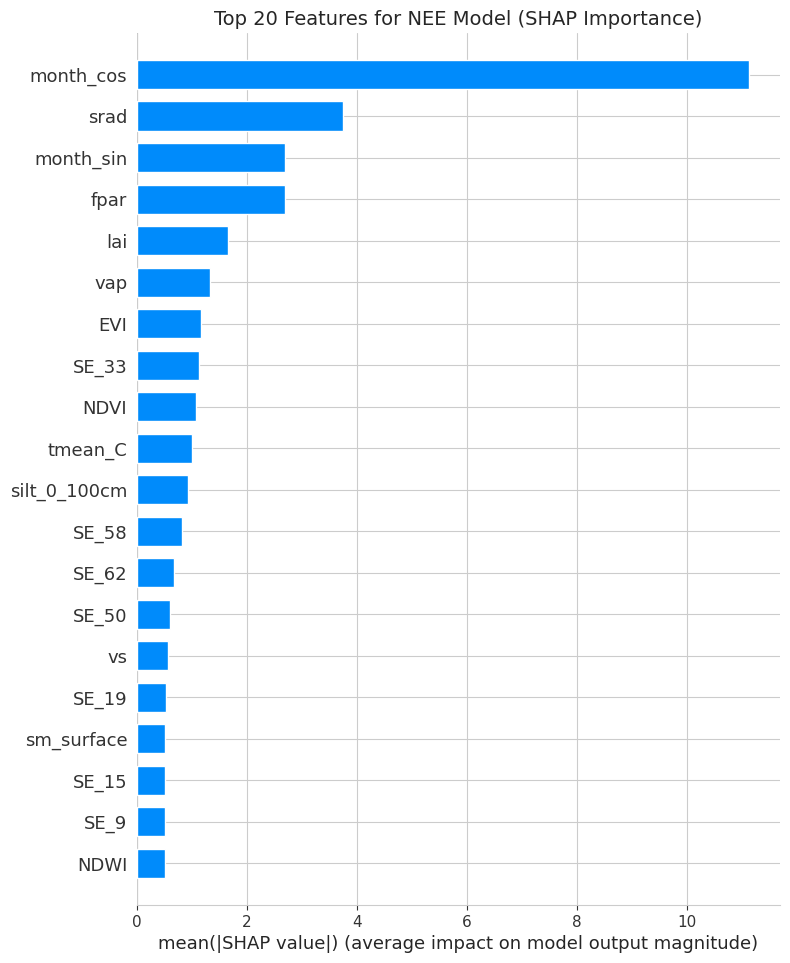

In [ ]:
# --- 2. Define Optimal Hyperparameters from Tuning ---
# We use the same optimal parameters for a fair comparison.
best_gpp_params = {
    'objective': 'regression_l2', 'metric': 'rmse', 'verbose': -1, 'n_jobs': -1,
    'seed': 42, 'boosting_type': 'gbdt', 'device': 'gpu', 'n_estimators': 2000,
    'learning_rate': 0.033810977573804024, 'num_leaves': 72, 'max_depth': 6,
    'min_child_samples': 25, 'lambda_l1': 0.011145963089939459,
    'lambda_l2': 4.0958991368657396e-08, 'feature_fraction': 0.6401199441482981,
    'bagging_fraction': 0.7436807084803926, 'bagging_freq': 3,
}
best_reco_params = {
    'objective': 'regression_l2', 'metric': 'rmse', 'verbose': -1, 'n_jobs': -1,
    'seed': 42, 'boosting_type': 'gbdt', 'device': 'gpu', 'n_estimators': 2000,
    'learning_rate': 0.019237283215338078, 'num_leaves': 32, 'max_depth': 9,
    'min_child_samples': 34, 'lambda_l1': 0.003389741018653232,
    'lambda_l2': 7.932478047097878, 'feature_fraction': 0.6700513622055762,
    'bagging_fraction': 0.8555749747428999, 'bagging_freq': 6,
}
best_nee_params = best_gpp_params.copy()


# --- 3. Define and Run LOSO Cross-Validation ---
def loso_cross_validate(df, features, target_name, params, group_col='site_name'):
    print(f"\n--- Performing LOSO CV for target: {target_name.upper()} ---")
    model_df = df[df[target_name].notna()].copy()
    if model_df.empty:
        print(f"No data available for target {target_name}. Skipping.")
        return df, {'r2': np.nan, 'rmse': np.nan}
    X = model_df[features]
    y = model_df[target_name]
    groups = model_df[group_col]
    logo = LeaveOneGroupOut()
    oof_preds = np.zeros(len(y))
    print(f"Iterating through {groups.nunique()} sites...")
    for train_idx, val_idx in logo.split(X, y, groups):
        X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
        X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]
        model = lgb.LGBMRegressor(**params)
        model.fit(X_train, y_train, eval_set=[(X_val, y_val)], eval_metric='rmse', callbacks=[lgb.early_stopping(100, verbose=False)])
        oof_preds[val_idx] = model.predict(X_val)
    df[f'{target_name}_pred_loso'] = np.nan
    df.loc[model_df.index, f'{target_name}_pred_loso'] = oof_preds
    overall_r2 = r2_score(y, oof_preds)
    overall_rmse = np.sqrt(mean_squared_error(y, oof_preds))
    print(f"LOSO CV R2 for {target_name.upper()}: {overall_r2:.4f}")
    print(f"LOSO CV RMSE for {target_name.upper()}: {overall_rmse:.4f}")
    metrics = {'r2': overall_r2, 'rmse': overall_rmse}
    return df, metrics

df_exp, gpp_metrics = loso_cross_validate(df_exp, final_features, 'gpp', best_gpp_params)
df_exp, reco_metrics = loso_cross_validate(df_exp, final_features, 'reco', best_reco_params)
df_exp, nee_metrics = loso_cross_validate(df_exp, final_features, 'nee', best_nee_params)
gc.collect()


# --- 4. Compare NEE Modeling Strategies for this Experiment ---
print("\n--- Comparing NEE Modeling Strategies (Post-2017 Experiment) ---")
eval_df = df_exp.dropna(subset=['nee', 'gpp_pred_loso', 'reco_pred_loso', 'nee_pred_loso']).copy()
if not eval_df.empty:
    eval_df['nee_pred_calculated'] = eval_df['reco_pred_loso'] - eval_df['gpp_pred_loso']
    nee_measured = eval_df['nee']
    calc_r2 = r2_score(nee_measured, eval_df['nee_pred_calculated'])
    calc_rmse = np.sqrt(mean_squared_error(nee_measured, eval_df['nee_pred_calculated']))
    model_r2 = r2_score(nee_measured, eval_df['nee_pred_loso'])
    model_rmse = np.sqrt(mean_squared_error(nee_measured, eval_df['nee_pred_loso']))
    print("\n--- Performance Summary (Post-2017 Experiment) ---")
    print(f"  Calculated NEE (reco-gpp): R2 = {calc_r2:.4f}, RMSE = {calc_rmse:.4f}")
    print(f"  Directly Modeled NEE:      R2 = {model_r2:.4f}, RMSE = {model_rmse:.4f}")
else:
    print("No overlapping NEE data to evaluate.")
    calc_r2, calc_rmse, model_r2, model_rmse = np.nan, np.nan, np.nan, np.nan

# --- 5. Save All Results for this Experiment ---
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
base_save_path = '/content/drive/MyDrive/Flux_upscaling/'
save_path = os.path.join(base_save_path, f'final_models_post2017_exp_{timestamp}/')
os.makedirs(save_path, exist_ok=True)
print(f"\n--- Saving models, logs, and figures to: {save_path} ---")

# (The rest of the script for saving plots, models, and logs is identical to previous versions)
# The full code is included for completeness.
def plot_and_save_actual_vs_predicted(df, actual_col, pred_col, save_path, model_name):
    plot_df = df.dropna(subset=[actual_col, pred_col]).copy()
    if plot_df.empty: return
    plt.figure(figsize=(8, 8))
    sns.set_style("whitegrid")
    r2 = r2_score(plot_df[actual_col], plot_df[pred_col])
    rmse = np.sqrt(mean_squared_error(plot_df[actual_col], plot_df[pred_col]))
    sns.scatterplot(x=plot_df[actual_col], y=plot_df[pred_col], alpha=0.5, s=15)
    min_val = min(plot_df[actual_col].min(), plot_df[pred_col].min())
    max_val = max(plot_df[actual_col].max(), plot_df[pred_col].max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)
    plt.title(f'Predicted vs. Actual for {model_name}\n$R^2 = {r2:.3f}$ | RMSE = {rmse:.3f}', fontsize=14)
    plt.xlabel('Actual (Measured) Values', fontsize=12)
    plt.ylabel('Predicted (LOSO) Values', fontsize=12)
    plt.axis('equal')
    plt.grid(True)
    fig_path = os.path.join(save_path, f'{model_name}_predicted_vs_actual.png')
    plt.savefig(fig_path, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"Saved {model_name} diagnostic plot.")

plot_and_save_actual_vs_predicted(df_exp, 'gpp', 'gpp_pred_loso', save_path, 'GPP')
plot_and_save_actual_vs_predicted(df_exp, 'reco', 'reco_pred_loso', save_path, 'RECO')
if not eval_df.empty:
    plot_and_save_actual_vs_predicted(eval_df, 'nee', 'nee_pred_loso', save_path, 'NEE_Direct_Model')
    plot_and_save_actual_vs_predicted(eval_df, 'nee', 'nee_pred_calculated', save_path, 'NEE_Calculated')

def train_save_and_plot_shap(df, features, target, params, save_path, model_name):
    print(f"\nTraining final {model_name} model on all data...")
    model_df = df[df[target].notna()]
    if model_df.empty:
        print(f"No data to train final {model_name} model. Skipping.")
        return None
    X_train = model_df[features]
    y_train = model_df[target]
    final_model = lgb.LGBMRegressor(**params).fit(X_train, y_train)
    joblib.dump(final_model, os.path.join(save_path, f'{model_name.lower()}_model_final.joblib'))
    print(f"Final {model_name} model saved.")
    print(f"Calculating and saving SHAP plot for {model_name}...")
    explainer = shap.TreeExplainer(final_model)
    shap_values = explainer.shap_values(X_train)
    shap.summary_plot(shap_values, X_train, plot_type="bar", max_display=20, show=False)
    plt.title(f'Top 20 Features for {model_name} Model (SHAP Importance)', fontsize=14)
    fig_path = os.path.join(save_path, f'{model_name}_shap_importance.png')
    plt.savefig(fig_path, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"Saved {model_name} SHAP plot.")
    return final_model

gpp_final_model = train_save_and_plot_shap(df_exp, final_features, 'gpp', best_gpp_params, save_path, 'GPP')
reco_final_model = train_save_and_plot_shap(df_exp, final_features, 'reco', best_reco_params, save_path, 'RECO')
nee_final_model = train_save_and_plot_shap(df_exp, final_features, 'nee', best_nee_params, save_path, 'NEE')

log_data = {
    "experiment_name": "Post-2017 Data Only",
    "run_timestamp": datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    "validation_method": "Leave-One-Site-Out Cross-Validation",
    "gpp_model_params": best_gpp_params, "reco_model_params": best_reco_params, "nee_model_params": best_nee_params,
    "performance_metrics": {
        "gpp_loso_r2": gpp_metrics['r2'], "gpp_loso_rmse": gpp_metrics['rmse'],
        "reco_loso_r2": reco_metrics['r2'], "reco_loso_rmse": reco_metrics['rmse'],
        "nee_direct_model_loso_r2": nee_metrics['r2'], "nee_direct_model_loso_rmse": nee_metrics['rmse'],
        "nee_calculated_loso_r2": calc_r2, "nee_calculated_loso_rmse": calc_rmse
    },
    "features_used": final_features
}
log_file_path = os.path.join(save_path, 'run_log.json')
with open(log_file_path, 'w') as f:
    class NpEncoder(json.JSONEncoder):
        def default(self, obj):
            if isinstance(obj, np.integer): return int(obj)
            if isinstance(obj, np.floating): return float(obj)
            if isinstance(obj, np.ndarray): return obj.tolist()
            return super(NpEncoder, self).default(obj)
    json.dump(log_data, f, indent=4, cls=NpEncoder)
print(f"\nRun log saved to {log_file_path}")
print("\n--- Post-2017 Experiment Complete. ---")


# exp4


In [ ]:
print("--- Starting Final Model Comparison for No Satellite Embedding Experiment ---")

# --- 1. Create the Experimental Feature List (without SE) ---
print("\nCreating experimental feature list by removing all 64 SE features...")
# This uses the 'final_features' list assumed to be in memory from previous scripts
# and filters out the 'SE_' columns.
experimental_features = [feat for feat in final_features if not feat.startswith('SE_')]
print(f"Number of features in this experiment: {len(experimental_features)}")
print(f"Original number of features: {len(final_features)}")

--- Starting Final Model Comparison for No Satellite Embedding Experiment ---

Creating experimental feature list by removing all 64 SE features...
Number of features in this experiment: 39
Original number of features: 103


In [ ]:
# --- 2. Define Optimal Hyperparameters from Tuning ---
# We use the same optimal parameters for a fair comparison of the feature sets.
best_gpp_params = {
    'objective': 'regression_l2', 'metric': 'rmse', 'verbose': -1, 'n_jobs': -1,
    'seed': 42, 'boosting_type': 'gbdt', 'device': 'gpu', 'n_estimators': 2000,
    'learning_rate': 0.033810977573804024, 'num_leaves': 72, 'max_depth': 6,
    'min_child_samples': 25, 'lambda_l1': 0.011145963089939459,
    'lambda_l2': 4.0958991368657396e-08, 'feature_fraction': 0.6401199441482981,
    'bagging_fraction': 0.7436807084803926, 'bagging_freq': 3,
}
best_reco_params = {
    'objective': 'regression_l2', 'metric': 'rmse', 'verbose': -1, 'n_jobs': -1,
    'seed': 42, 'boosting_type': 'gbdt', 'device': 'gpu', 'n_estimators': 2000,
    'learning_rate': 0.019237283215338078, 'num_leaves': 32, 'max_depth': 9,
    'min_child_samples': 34, 'lambda_l1': 0.003389741018653232,
    'lambda_l2': 7.932478047097878, 'feature_fraction': 0.6700513622055762,
    'bagging_fraction': 0.8555749747428999, 'bagging_freq': 6,
}
best_nee_params = best_gpp_params.copy()


# --- 3. Define and Run LOSO Cross-Validation ---
# This reuses the same robust validation function from previous scripts
def loso_cross_validate(df, features, target_name, params, group_col='site_name'):
    print(f"\n--- Performing LOSO CV for target: {target_name.upper()} ---")
    model_df = df[df[target_name].notna()].copy()
    X = model_df[features]
    y = model_df[target_name]
    groups = model_df[group_col]
    logo = LeaveOneGroupOut()
    oof_preds = np.zeros(len(y))
    print(f"Iterating through {groups.nunique()} sites...")
    for train_idx, val_idx in logo.split(X, y, groups):
        X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
        X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]
        model = lgb.LGBMRegressor(**params)
        model.fit(X_train, y_train, eval_set=[(X_val, y_val)], eval_metric='rmse', callbacks=[lgb.early_stopping(100, verbose=False)])
        oof_preds[val_idx] = model.predict(X_val)
    df[f'{target_name}_pred_loso'] = np.nan
    df.loc[model_df.index, f'{target_name}_pred_loso'] = oof_preds
    overall_r2 = r2_score(y, oof_preds)
    overall_rmse = np.sqrt(mean_squared_error(y, oof_preds))
    print(f"LOSO CV R2 for {target_name.upper()}: {overall_r2:.4f}")
    print(f"LOSO CV RMSE for {target_name.upper()}: {overall_rmse:.4f}")
    metrics = {'r2': overall_r2, 'rmse': overall_rmse}
    return df, metrics

# We use the original full df_train for this experiment
df_exp, gpp_metrics = loso_cross_validate(df_train, experimental_features, 'gpp', best_gpp_params)
df_exp, reco_metrics = loso_cross_validate(df_train, experimental_features, 'reco', best_reco_params)
df_exp, nee_metrics = loso_cross_validate(df_train, experimental_features, 'nee', best_nee_params)
gc.collect()


# --- 4. Compare NEE Modeling Strategies for this Experiment ---
print("\n--- Comparing NEE Modeling Strategies (No SE Experiment) ---")
eval_df = df_exp.dropna(subset=['nee', 'gpp_pred_loso', 'reco_pred_loso', 'nee_pred_loso']).copy()
eval_df['nee_pred_calculated'] = eval_df['reco_pred_loso'] - eval_df['gpp_pred_loso']
nee_measured = eval_df['nee']
calc_r2 = r2_score(nee_measured, eval_df['nee_pred_calculated'])
calc_rmse = np.sqrt(mean_squared_error(nee_measured, eval_df['nee_pred_calculated']))
model_r2 = r2_score(nee_measured, eval_df['nee_pred_loso'])
model_rmse = np.sqrt(mean_squared_error(nee_measured, eval_df['nee_pred_loso']))
print("\n--- Performance Summary (No SE Experiment) ---")
print(f"  Calculated NEE (reco-gpp): R2 = {calc_r2:.4f}, RMSE = {calc_rmse:.4f}")
print(f"  Directly Modeled NEE:      R2 = {model_r2:.4f}, RMSE = {model_rmse:.4f}")


# --- 5. Save All Results for this Experiment ---
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
base_save_path = '/content/drive/MyDrive/Flux_upscaling/'
save_path = os.path.join(base_save_path, f'final_models_exp4_{timestamp}/')
os.makedirs(save_path, exist_ok=True)
print(f"\n--- Saving models, logs, and figures to: {save_path} ---")

# (The rest of the script for saving plots, models, and logs is identical to previous versions)
def plot_and_save_actual_vs_predicted(df, actual_col, pred_col, save_path, model_name):
    plot_df = df.dropna(subset=[actual_col, pred_col]).copy()
    if plot_df.empty: return
    plt.figure(figsize=(8, 8))
    sns.set_style("whitegrid")
    r2 = r2_score(plot_df[actual_col], plot_df[pred_col])
    rmse = np.sqrt(mean_squared_error(plot_df[actual_col], plot_df[pred_col]))
    sns.scatterplot(x=plot_df[actual_col], y=plot_df[pred_col], alpha=0.5, s=15)
    min_val = min(plot_df[actual_col].min(), plot_df[pred_col].min())
    max_val = max(plot_df[actual_col].max(), plot_df[pred_col].max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)
    plt.title(f'Predicted vs. Actual for {model_name}\n$R^2 = {r2:.3f}$ | RMSE = {rmse:.3f}', fontsize=14)
    plt.xlabel('Actual (Measured) Values', fontsize=12)
    plt.ylabel('Predicted (LOSO) Values', fontsize=12)
    plt.axis('equal')
    plt.grid(True)
    fig_path = os.path.join(save_path, f'{model_name}_predicted_vs_actual.png')
    plt.savefig(fig_path, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"Saved {model_name} diagnostic plot.")

plot_and_save_actual_vs_predicted(df_exp, 'gpp', 'gpp_pred_loso', save_path, 'GPP')
plot_and_save_actual_vs_predicted(df_exp, 'reco', 'reco_pred_loso', save_path, 'RECO')
plot_and_save_actual_vs_predicted(eval_df, 'nee', 'nee_pred_loso', save_path, 'NEE_Direct_Model')
plot_and_save_actual_vs_predicted(eval_df, 'nee', 'nee_pred_calculated', save_path, 'NEE_Calculated')

def train_save_and_plot_shap(df, features, target, params, save_path, model_name):
    print(f"\nTraining final {model_name} model on all data...")
    model_df = df[df[target].notna()]
    X_train = model_df[features]
    y_train = model_df[target]
    final_model = lgb.LGBMRegressor(**params).fit(X_train, y_train)
    joblib.dump(final_model, os.path.join(save_path, f'{model_name.lower()}_model_final.joblib'))
    print(f"Final {model_name} model saved.")
    print(f"Calculating and saving SHAP plot for {model_name}...")
    explainer = shap.TreeExplainer(final_model)
    shap_values = explainer.shap_values(X_train)
    shap.summary_plot(shap_values, X_train, plot_type="bar", max_display=20, show=False)
    plt.title(f'Top 20 Features for {model_name} Model (SHAP Importance)', fontsize=14)
    fig_path = os.path.join(save_path, f'{model_name}_shap_importance.png')
    plt.savefig(fig_path, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"Saved {model_name} SHAP plot.")
    return final_model

gpp_final_model = train_save_and_plot_shap(df_exp, experimental_features, 'gpp', best_gpp_params, save_path, 'GPP')
reco_final_model = train_save_and_plot_shap(df_exp, experimental_features, 'reco', best_reco_params, save_path, 'RECO')
nee_final_model = train_save_and_plot_shap(df_exp, experimental_features, 'nee', best_nee_params, save_path, 'NEE')

log_data = {
    "experiment_name": "Without Satellite Embeddings",
    "run_timestamp": datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    "validation_method": "Leave-One-Site-Out Cross-Validation",
    "gpp_model_params": best_gpp_params, "reco_model_params": best_reco_params, "nee_model_params": best_nee_params,
    "performance_metrics": {
        "gpp_loso_r2": gpp_metrics['r2'], "gpp_loso_rmse": gpp_metrics['rmse'],
        "reco_loso_r2": reco_metrics['r2'], "reco_loso_rmse": reco_metrics['rmse'],
        "nee_direct_model_loso_r2": nee_metrics['r2'], "nee_direct_model_loso_rmse": nee_metrics['rmse'],
        "nee_calculated_loso_r2": calc_r2, "nee_calculated_loso_rmse": calc_rmse
    },
    "features_used": experimental_features
}
log_file_path = os.path.join(save_path, 'run_log.json')
with open(log_file_path, 'w') as f:
    class NpEncoder(json.JSONEncoder):
        def default(self, obj):
            if isinstance(obj, np.integer): return int(obj)
            if isinstance(obj, np.floating): return float(obj)
            if isinstance(obj, np.ndarray): return obj.tolist()
            return super(NpEncoder, self).default(obj)
    json.dump(log_data, f, indent=4, cls=NpEncoder)
print(f"\nRun log saved to {log_file_path}")
print("\n--- No Satellite Embedding Experiment Complete. ---")



--- Performing LOSO CV for target: GPP ---
Iterating through 138 sites...
LOSO CV R2 for GPP: 0.8028
LOSO CV RMSE for GPP: 32.5610

--- Performing LOSO CV for target: RECO ---
Iterating through 138 sites...
LOSO CV R2 for RECO: 0.7439
LOSO CV RMSE for RECO: 28.9477

--- Performing LOSO CV for target: NEE ---
Iterating through 171 sites...
LOSO CV R2 for NEE: 0.5822
LOSO CV RMSE for NEE: 20.1211

--- Comparing NEE Modeling Strategies (No SE Experiment) ---

--- Performance Summary (No SE Experiment) ---
  Calculated NEE (reco-gpp): R2 = 0.5317, RMSE = 21.3382
  Directly Modeled NEE:      R2 = 0.5935, RMSE = 19.8817

--- Saving models, logs, and figures to: /content/drive/MyDrive/Flux_upscaling/final_models_exp4_20251013_182248/ ---
Saved GPP diagnostic plot.
Saved RECO diagnostic plot.
Saved NEE_Direct_Model diagnostic plot.
Saved NEE_Calculated diagnostic plot.

Training final GPP model on all data...
Final GPP model saved.
Calculating and saving SHAP plot for GPP...
Saved GPP SHAP pl

# CH4 selected sites exp

In [ ]:
print("--- Starting Final Model Comparison for CH4 Curated Sites Experiment ---")

# --- 1. Define Curated Site List and Create Experimental DataFrame ---
curated_sites = [
    'ARM-NSA-Barrow_US-A10_tower', 'Barrow-BEO_US-Beo_tower',
    'Barrow-BES-US-Bes_tower', 'Barrow-CMDL-US-Brw_tower',
    'NGEE Arctic Barrow_USNGB_tower', 'FOCAL US-Fo1 (Campaign)_tower',
    'FOCAL US-Fo2 (Campaign)_tower', 'Atqasuk_US-Atq_tower',
    'Ivotuk_US-Ivo_tower', 'Imnavait_Creek_US-Ics_tower',
    'NGEE Arctic Countil_US-NGC_tower', 'Eight Mile Lake_US-EML_tower',
    'Bonanza Creek Black Spruce_US-BZS_tower',
    'Bonanza Creek Rich Fen_US-BZF_tower',
    'Bonanza Creek Thermokarst Bog_US-BZB_tower', 'US-Uaf_tower',
    'YKD_unburned_US-YK2_tower', 'Lily Lake Fen_US-KPL_tower',
    'Trail Valley Creek_CA-TVC_tower', 'Smith Creek_CA-SMC_tower',
    'Scotty Creek Bog_CA-SCB_tower', 'Scotty Creek _CA_SCC_tower',
    'Havikpak Creek_CA-HPC_tower', 'Churchill Fen 3_CA-CF3_tower',
    'Churchill Fen Site 2_CA-CF2_tower', 'Bouleau peatland_CA-BOU_tower',
    'HowlandForest_US-Ho1_tower', 'Rylekaerene_tower', 'Iskoras_NO-Isk_tower',
    'Iskoras_NO-Isk-fen_tower', 'Iskoras_NO-Isk-palsa_tower',
    'Stordalen Palsa Bog_SE-Sto_tower', 'Stortjarn-SE-Srj_tower',
    'Stordalen Fen_SE-St1_tower', 'Halmyran_SE-Hmr_tower',
    'Halsingfors mire_SE-HfM_tower', 'Degero_SE-Deg_tower',
    'Siikaneva_FI-Siii_tower', 'Siikaneva2_FI-Si2_tower',
    'Pitsalu_EE-Pts_tower', 'Kytalyk_RU-Cok_tower',
    'Cherskii reference_RU-Ch2_tower', 'Seida_RU-Vrk_tower',
    'North Star Yedoma_US-NSY_tower', 'Bernard spruce-moss valley_tower',
    'Delta Burns Bog 2_CA-DB2_tower', 'Delta Burns Bog_CA-DBB_tower',
    'Newdale Manitoba_CA-EM1_tower', 'Shoal Lake Manitoba_CA-EM2_tower',
    'Allequash Creek Site_US-ALQ_tower',
    'Howland Forest (main tower)_US-Ho1_tower',
    'Lost Creek_US-Los_tower', 'Marcell Bog Lake Peatland_US-MBP_tower',
    'Park Falls/WLEF_US-PFa_tower', 'Trout Bog_US-TrB_tower',
    'Trout Lake Area South Sparkling Bog_US-TrS_tower'
]

print(f"\nFiltering dataframe to {len(curated_sites)} curated sites...")
df_exp = df_train[df_train['site_reference'].isin(curated_sites)].copy()
print(f"Shape of the new experimental dataframe: {df_exp.shape}")


--- Starting Final Model Comparison for CH4 Curated Sites Experiment ---

Filtering dataframe to 56 curated sites...
Shape of the new experimental dataframe: (2450, 138)


In [ ]:
# --- 2. Define Hyperparameters ---
# Using the best parameters from GPP tuning, as requested.
best_ch4_params = {
    'objective': 'regression_l2', 'metric': 'rmse', 'verbose': -1, 'n_jobs': -1,
    'seed': 42, 'boosting_type': 'gbdt', 'device': 'gpu', 'n_estimators': 2000,
    'learning_rate': 0.033810977573804024, 'num_leaves': 72, 'max_depth': 6,
    'min_child_samples': 25, 'lambda_l1': 0.011145963089939459,
    'lambda_l2': 4.0958991368657396e-08, 'feature_fraction': 0.6401199441482981,
    'bagging_fraction': 0.7436807084803926, 'bagging_freq': 3,
}

# --- 3. Define and Run LOSO Cross-Validation ---
def loso_cross_validate(df, features, target_name, params, group_col='site_name'):
    print(f"\n--- Performing LOSO CV for target: {target_name.upper()} ---")
    model_df = df[df[target_name].notna()].copy()
    if model_df.empty:
        print(f"No data available for target {target_name} with the selected sites. Aborting.")
        return df, {'r2': np.nan, 'rmse': np.nan}
    X = model_df[features]
    y = model_df[target_name]
    groups = model_df[group_col]
    logo = LeaveOneGroupOut()
    oof_preds = np.zeros(len(y))
    print(f"Iterating through {groups.nunique()} sites with CH4 data...")
    for train_idx, val_idx in logo.split(X, y, groups):
        X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
        X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]
        model = lgb.LGBMRegressor(**params)
        model.fit(X_train, y_train, eval_set=[(X_val, y_val)], eval_metric='rmse', callbacks=[lgb.early_stopping(100, verbose=False)])
        oof_preds[val_idx] = model.predict(X_val)
    df[f'{target_name}_pred_loso'] = np.nan
    df.loc[model_df.index, f'{target_name}_pred_loso'] = oof_preds
    overall_r2 = r2_score(y, oof_preds)
    overall_rmse = np.sqrt(mean_squared_error(y, oof_preds))
    print(f"LOSO CV R2 for {target_name.upper()}: {overall_r2:.4f}")
    print(f"LOSO CV RMSE for {target_name.upper()}: {overall_rmse:.4f}")
    metrics = {'r2': overall_r2, 'rmse': overall_rmse}
    return df, metrics

df_exp, ch4_metrics = loso_cross_validate(df_exp, final_features, 'ch4_flux_total', best_ch4_params)
gc.collect()

# --- 4. Save All Results for this Experiment ---
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
base_save_path = '/content/drive/MyDrive/Flux_upscaling/'
save_path = os.path.join(base_save_path, f'final_models_ch4_curated_exp_{timestamp}/')
os.makedirs(save_path, exist_ok=True)
print(f"\n--- Saving models, logs, and figures to: {save_path} ---")

def plot_and_save_actual_vs_predicted(df, actual_col, pred_col, save_path, model_name):
    plot_df = df.dropna(subset=[actual_col, pred_col]).copy()
    if plot_df.empty: return
    plt.figure(figsize=(8, 8))
    sns.set_style("whitegrid")
    r2 = r2_score(plot_df[actual_col], plot_df[pred_col])
    rmse = np.sqrt(mean_squared_error(plot_df[actual_col], plot_df[pred_col]))
    sns.scatterplot(x=plot_df[actual_col], y=plot_df[pred_col], alpha=0.5, s=15)
    min_val = min(plot_df[actual_col].min(), plot_df[pred_col].min())
    max_val = max(plot_df[actual_col].max(), plot_df[pred_col].max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)
    plt.title(f'Predicted vs. Actual for {model_name}\n$R^2 = {r2:.3f}$ | RMSE = {rmse:.3f}', fontsize=14)
    plt.xlabel('Actual (Measured) Values', fontsize=12)
    plt.ylabel('Predicted (LOSO) Values', fontsize=12)
    plt.axis('equal')
    plt.grid(True)
    fig_path = os.path.join(save_path, f'{model_name}_predicted_vs_actual.png')
    plt.savefig(fig_path, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"Saved {model_name} diagnostic plot.")

plot_and_save_actual_vs_predicted(df_exp, 'ch4_flux_total', 'ch4_flux_total_pred_loso', save_path, 'CH4_Curated')

def train_save_and_plot_shap(df, features, target, params, save_path, model_name):
    print(f"\nTraining final {model_name} model on all data...")
    model_df = df[df[target].notna()]
    if model_df.empty:
        print(f"No data to train final {model_name} model. Skipping.")
        return None
    X_train = model_df[features]
    y_train = model_df[target]
    final_model = lgb.LGBMRegressor(**params).fit(X_train, y_train)
    joblib.dump(final_model, os.path.join(save_path, f'{model_name.lower()}_model_final.joblib'))
    print(f"Final {model_name} model saved.")
    print(f"Calculating and saving SHAP plot for {model_name}...")
    explainer = shap.TreeExplainer(final_model)
    shap_values = explainer.shap_values(X_train)
    shap.summary_plot(shap_values, X_train, plot_type="bar", max_display=20, show=False)
    plt.title(f'Top 20 Features for {model_name} Model (SHAP Importance)', fontsize=14)
    fig_path = os.path.join(save_path, f'{model_name}_shap_importance.png')
    plt.savefig(fig_path, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"Saved {model_name} SHAP plot.")
    return final_model

ch4_final_model = train_save_and_plot_shap(df_exp, final_features, 'ch4_flux_total', best_ch4_params, save_path, 'CH4_Curated')

log_data = {
    "experiment_name": "CH4 Model with Curated High-Quality Sites",
    "run_timestamp": datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    "validation_method": "Leave-One-Site-Out Cross-Validation",
    "ch4_model_params": best_ch4_params,
    "performance_metrics": {
        "ch4_loso_r2": ch4_metrics['r2'],
        "ch4_loso_rmse": ch4_metrics['rmse']
    },
    "sites_used": curated_sites,
    "features_used": final_features
}
log_file_path = os.path.join(save_path, 'run_log.json')
with open(log_file_path, 'w') as f:
    class NpEncoder(json.JSONEncoder):
        def default(self, obj):
            if isinstance(obj, np.integer): return int(obj)
            if isinstance(obj, np.floating): return float(obj)
            if isinstance(obj, np.ndarray): return obj.tolist()
            return super(NpEncoder, self).default(obj)
    json.dump(log_data, f, indent=4, cls=NpEncoder)
print(f"\nRun log saved to {log_file_path}")
print("\n--- CH4 Curated Sites Experiment Complete. ---")



--- Performing LOSO CV for target: CH4_FLUX_TOTAL ---
Iterating through 28 sites with CH4 data...
LOSO CV R2 for CH4_FLUX_TOTAL: 0.3007
LOSO CV RMSE for CH4_FLUX_TOTAL: 0.7243

--- Saving models, logs, and figures to: /content/drive/MyDrive/Flux_upscaling/final_models_ch4_curated_exp_20251013_183456/ ---
Saved CH4_Curated diagnostic plot.

Training final CH4_Curated model on all data...
Final CH4_Curated model saved.
Calculating and saving SHAP plot for CH4_Curated...
Saved CH4_Curated SHAP plot.

Run log saved to /content/drive/MyDrive/Flux_upscaling/final_models_ch4_curated_exp_20251013_183456/run_log.json

--- CH4 Curated Sites Experiment Complete. ---


# 10.16 exp 2.1

In [ ]:
# ---------------------------------------------------------------------------
# Block 9: Experiment 2.1 Full Pipeline (Corrected)
#
# This script executes the complete workflow for Experiment 2.1:
# 1. Loads the v5 dataset, merges embeddings, and engineers only tmean_C.
# 2. Uses the exact PREDICTORS list provided.
# 3. Sets pre-2017 SE data to NaN.
# 4. Tunes hyperparameters for NEE and CH4 using LOSO CV.
# 5. Runs a final LOSO CV evaluation on all four targets.
# 6. Saves all final models, plots, and logs into a timestamped folder.
# ---------------------------------------------------------------------------

  # --- 1. Load and Prepare Data ---
  print("\n--- Step 1: Loading and Preparing Data ---")

  v5_data_path = '/content/drive/MyDrive/Flux_upscaling/model_training_data_v5.csv'
  se_data_path = '/content/drive/MyDrive/Flux_upscaling/satellite_embeddings.csv'

  print(f"Loading new v5 data from: {v5_data_path}")
  df_train = pd.read_csv(v5_data_path)
  print(f"Loading satellite embeddings from: {se_data_path}")
  df_se = pd.read_csv(se_data_path)

  print("Merging dataframes...")
  se_cols_to_drop = [col for col in df_train.columns if col.startswith('SE_')]
  df_train.drop(columns=se_cols_to_drop, inplace=True, errors='ignore')
  df_train = pd.merge(df_train, df_se, on=['site_name', 'year'], how='left')

  print("\nEnforcing NaN values for pre-2017 Satellite Embeddings...")
  se_features = [f'SE_{i}' for i in range(64)]
  pre_2017_mask = df_train['year'] < 2017
  df_train.loc[pre_2017_mask, se_features] = np.nan
  print(f"Set SE values to NaN for {pre_2017_mask.sum()} rows where year < 2017.")

  # --- On-the-fly Feature Engineering ---
  print("\nEngineering on-the-fly features...")
  df_train['tmean_C'] = (df_train['tmmn'] + df_train['tmmx']) / 2
  print("Created 'tmean_C' feature.")

  # Define final feature set exactly as specified
  PREDICTORS_BASE = [
      'EVI', 'NDVI', 'sur_refl_b01', 'sur_refl_b02', 'sur_refl_b03',
      'sur_refl_b07', 'NDWI', 'pdsi', 'srad', 'tmean_C', 'vap', 'vs', 'swe',
      'aet', 'pet', 'def',
      'bdod_0_100cm', 'cec_0_100cm', 'cfvo_0_100cm', 'clay_0_100cm',
      'nitrogen_0_100cm', 'ocd_0_100cm', 'phh2o_0_100cm', 'sand_0_100cm',
      'silt_0_100cm', 'soc_0_100cm', 'co2_cont', 'ALT',
      'land_cover', 'month',
      'lai', 'fpar', 'Percent_NonTree_Vegetation',
      'Percent_NonVegetated', 'Percent_Tree_Cover', 'sm_surface', 'sm_rootzone',
      'snow_cover', 'snow_depth', 'soil_temperature_level_1', 'soil_temperature_level_2',
      'soil_temperature_level_3', 'soil_temperature_level_4',
      'N_N_0_100cm', 'alpha_ALFA_0_100cm', 'crit_wilt_CRIT-WILT_0_100cm',
      'field_crit_FIELD-CRIT_0_100cm', 'ksat_Ksat_0_100cm', 'ormc_ORMC_0_100cm',
      'satfield_SAT-FIELD_0_100cm', 'stc_STC_0_100cm', 'wcavail_WCavail_0_100cm',
      'wcpf2_WCpF2_0_100cm', 'wcpf3_WCpF3_0_100cm', 'wcpf4_2_WCpF4-2_0_100cm',
      'wcres_WCres_0_100cm', 'wcsat_WCsat_0_100cm'
  ]

  # Remove 'month' as it will be replaced by sinusoidal features
  PREDICTORS = [p for p in PREDICTORS_BASE if p != 'month']

  df_train['month_sin'] = np.sin(2 * np.pi * df_train['month']/12)
  df_train['month_cos'] = np.cos(2 * np.pi * df_train['month']/12)
  df_train['latitude_sin'] = np.sin(np.deg2rad(df_train['latitude']))
  df_train['latitude_cos'] = np.cos(np.deg2rad(df_train['latitude']))
  df_train['longitude_sin'] = np.sin(np.deg2rad(df_train['longitude']))
  df_train['longitude_cos'] = np.cos(np.deg2rad(df_train['longitude']))
  engineered_features = ['month_sin', 'month_cos', 'latitude_sin', 'latitude_cos', 'longitude_sin', 'longitude_cos']

  final_features = PREDICTORS + engineered_features + se_features

  # Check for any missing columns from the PREDICTORS list
  for col in final_features:
      if col not in df_train.columns:
          df_train[col] = np.nan
          print(f"Warning: Feature column '{col}' was not found or created. Added as all NaN.")

  print("Data preparation complete.")


--- Step 1: Loading and Preparing Data ---
Loading new v5 data from: /content/drive/MyDrive/Flux_upscaling/model_training_data_v5.csv


/tmp/ipython-input-4109584889.py:20: DtypeWarning: Columns (134,135) have mixed types. Specify dtype option on import or set low_memory=False.
  df_train = pd.read_csv(v5_data_path)


Loading satellite embeddings from: /content/drive/MyDrive/Flux_upscaling/satellite_embeddings.csv
Merging dataframes...

Enforcing NaN values for pre-2017 Satellite Embeddings...
Set SE values to NaN for 437301 rows where year < 2017.

Engineering on-the-fly features...
Created 'tmean_C' feature.
Data preparation complete.


In [ ]:
df_train

,site_name,site_reference,latitude,longitude,flux_method,country,land_cover_eco,land_cover_plot,bawld_class,year,...,ksat_Ksat_0_100cm,ormc_ORMC_0_100cm,satfield_SAT-FIELD_0_100cm,stc_STC_0_100cm,wcavail_WCavail_0_100cm,wcpf2_WCpF2_0_100cm,wcpf3_WCpF3_0_100cm,wcpf4_2_WCpF4-2_0_100cm,wcres_WCres_0_100cm,wcsat_WCsat_0_100cm
0,Bonanza Creek Experimental Forest,Bonanza Creek Experimental Forest_FP1A-Sandbar...,64.680000,-148.316667,Chamber,USA,90.0,90.0,Boreal Forest,2000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Bonanza Creek Experimental Forest,Bonanza Creek Experimental Forest_FP2A-Alder-P...,64.680000,-148.316667,Chamber,USA,90.0,90.0,Boreal Forest,2000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Bonanza Creek Experimental Forest,Bonanza Creek Experimental Forest_FP3A-Poplar_...,64.680000,-148.316667,Chamber,USA,90.0,90.0,Boreal Forest,2000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Bonanza Creek Experimental Forest,Bonanza Creek Experimental Forest_FP4A-White S...,64.680000,-148.316667,Chamber,USA,90.0,90.0,Boreal Forest,2000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Bonanza Creek Experimental Forest,Bonanza Creek Experimental Forest_FP5A- Black ...,64.680000,-148.316667,Chamber,USA,90.0,90.0,Permafrost Bog,2000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
642650,Zackenberg Heath,Zackenberg Heath_GL-ZaH_tower,74.473300,-20.550869,EC,Greenland,121.0,121.0,Dry Tundra,1997,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
642651,Zotino; Central Siberia,Zotino; Central Siberia_RU-Zfw 1_tower,60.750000,89.380000,EC,Russia,70.0,70.0,Boreal Forest,1999,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
642652,Zotino; Central Siberia,Zotino; Central Siberia_RU-Zfw 2_tower,60.758049,89.390000,EC,Russia,70.0,70.0,Boreal Forest,1999,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
642653,Zotino; Central Siberia,Zotino; Central Siberia_RU-Zfw 2_tower,60.758049,89.390000,EC,Russia,70.0,70.0,Boreal Forest,1999,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:


    # --- 2. Hyperparameter Tuning for NEE and CH4 ---
    print("\n--- Step 2: Hyperparameter Tuning ---")

    def tuning_objective(trial, df, features, target):
        params = { 'objective': 'regression_l2', 'metric': 'rmse', 'verbose': -1, 'n_jobs': -1, 'seed': 42, 'boosting_type': 'gbdt', 'device': 'gpu', 'n_estimators': 1000,
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True), 'num_leaves': trial.suggest_int('num_leaves', 20, 100), 'max_depth': trial.suggest_int('max_depth', 5, 20),
            'min_child_samples': trial.suggest_int('min_child_samples', 5, 50), 'lambda_l1': trial.suggest_float('lambda_l1', 1e-8, 10.0, log=True), 'lambda_l2': trial.suggest_float('lambda_l2', 1e-8, 10.0, log=True),
            'feature_fraction': trial.suggest_float('feature_fraction', 0.6, 1.0), 'bagging_fraction': trial.suggest_float('bagging_fraction', 0.6, 1.0), 'bagging_freq': trial.suggest_int('bagging_freq', 1, 7) }
        model_df = df[df[target].notna()]
        X, y, groups = model_df[features], model_df[target], model_df['site_name']
        logo, rmse_scores = LeaveOneGroupOut(), []
        unique_sites = groups.unique()
        if len(unique_sites) > 50:
             sites_to_tune = np.random.choice(unique_sites, 50, replace=False)
             tune_indices = model_df[model_df['site_name'].isin(sites_to_tune)].index
             X, y, groups = X.loc[tune_indices], y.loc[tune_indices], groups.loc[tune_indices]
        for train_idx, val_idx in logo.split(X, y, groups):
            if len(val_idx) == 0 or len(train_idx) == 0: continue
            X_train, y_train, X_val, y_val = X.iloc[train_idx], y.iloc[train_idx], X.iloc[val_idx], y.iloc[val_idx]
            model = lgb.LGBMRegressor(**params)
            model.fit(X_train, y_train, eval_set=[(X_val, y_val)], eval_metric='rmse', callbacks=[lgb.early_stopping(50, verbose=False)])
            rmse_scores.append(np.sqrt(mean_squared_error(y_val, model.predict(X_val))))
        return np.mean(rmse_scores)

    print("\nTuning nee model...")
    study_nee = optuna.create_study(direction='minimize')
    study_nee.optimize(lambda trial: tuning_objective(trial, df_train, final_features, 'nee'), n_trials=50)
    best_nee_params = study_nee.best_params
    print("Best hyperparameters for nee:", best_nee_params)

    print("\nTuning ch4_flux_total model...")
    study_ch4 = optuna.create_study(direction='minimize')
    study_ch4.optimize(lambda trial: tuning_objective(trial, df_train, final_features, 'ch4_flux_total'), n_trials=50)
    best_ch4_params = study_ch4.best_params
    print("Best hyperparameters for ch4_flux_total:", best_ch4_params)

    # --- 3. Final Model Evaluation with LOSO CV ---
    print("\n--- Step 3: Final Model Evaluation ---")

    core_params = {'objective': 'regression_l2', 'metric': 'rmse', 'verbose': -1, 'n_jobs': -1, 'seed': 42, 'boosting_type': 'gbdt', 'device': 'gpu', 'n_estimators': 2000}
    best_nee_params.update(core_params)
    best_ch4_params.update(core_params)
    best_gpp_params = {**core_params, 'learning_rate': 0.0338, 'num_leaves': 72, 'max_depth': 6, 'min_child_samples': 25, 'lambda_l1': 0.0111, 'lambda_l2': 4.1e-08, 'feature_fraction': 0.640, 'bagging_fraction': 0.743, 'bagging_freq': 3}
    best_reco_params = {**core_params, 'learning_rate': 0.0192, 'num_leaves': 32, 'max_depth': 9, 'min_child_samples': 34, 'lambda_l1': 0.0034, 'lambda_l2': 7.932, 'feature_fraction': 0.670, 'bagging_fraction': 0.855, 'bagging_freq': 6}

    def loso_cross_validate(df, features, target, params, group_col='site_name'):
        print(f"\n--- Performing LOSO CV for target: {target.upper()} ---")
        model_df = df[df[target].notna()]
        X, y, groups = model_df[features], model_df[target], model_df[group_col]
        logo, oof_preds = LeaveOneGroupOut(), np.zeros(len(y))
        print(f"Iterating through {groups.nunique()} sites...")
        for train_idx, val_idx in logo.split(X, y, groups):
            if len(val_idx) == 0 or len(train_idx) == 0: continue
            X_train, y_train, X_val, y_val = X.iloc[train_idx], y.iloc[train_idx], X.iloc[val_idx], y.iloc[val_idx]
            model = lgb.LGBMRegressor(**params)
            model.fit(X_train, y_train, eval_set=[(X_val, y_val)], eval_metric='rmse', callbacks=[lgb.early_stopping(100, verbose=False)])
            oof_preds[val_idx] = model.predict(X_val)
        df[f'{target}_pred_loso'] = np.nan
        df.loc[model_df.index, f'{target}_pred_loso'] = oof_preds
        metrics = {'r2': r2_score(y, oof_preds), 'rmse': np.sqrt(mean_squared_error(y, oof_preds))}
        print(f"LOSO CV R2 for {target.upper()}: {metrics['r2']:.4f}, RMSE: {metrics['rmse']:.4f}")
        return df, metrics

    df_train, gpp_metrics = loso_cross_validate(df_train, final_features, 'gpp', best_gpp_params)
    df_train, reco_metrics = loso_cross_validate(df_train, final_features, 'reco', best_reco_params)
    df_train, nee_metrics = loso_cross_validate(df_train, final_features, 'nee', best_nee_params)
    df_train, ch4_metrics = loso_cross_validate(df_train, final_features, 'ch4_flux_total', best_ch4_params)

    # --- 4. Save All Results ---
    print("\n--- Step 4: Saving All Results ---")
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    save_path = f'/content/drive/MyDrive/Flux_upscaling/exp_2_1_{timestamp}/'
    os.makedirs(save_path, exist_ok=True)
    print(f"Saving artifacts to: {save_path}")

    def plot_and_save_actual_vs_predicted(df, actual_col, pred_col, save_path, model_name):
        plot_df = df.dropna(subset=[actual_col, pred_col]).copy();
        if plot_df.empty: return
        plt.figure(figsize=(8, 8)); sns.set_style("whitegrid")
        r2, rmse = r2_score(plot_df[actual_col], plot_df[pred_col]), np.sqrt(mean_squared_error(plot_df[actual_col], plot_df[pred_col]))
        sns.scatterplot(x=plot_df[actual_col], y=plot_df[pred_col], alpha=0.5, s=15)
        min_val, max_val = min(plot_df[actual_col].min(), plot_df[pred_col].min()), max(plot_df[actual_col].max(), plot_df[pred_col].max())
        plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)
        plt.title(f'Predicted vs. Actual for {model_name}\n$R^2 = {r2:.3f}$ | RMSE = {rmse:.3f}', fontsize=14)
        plt.xlabel('Actual (Measured) Values', fontsize=12); plt.ylabel('Predicted (LOSO) Values', fontsize=12); plt.axis('equal'); plt.grid(True)
        plt.savefig(os.path.join(save_path, f'{model_name}_predicted_vs_actual.png'), dpi=300, bbox_inches='tight'); plt.close()
        print(f"Saved {model_name} diagnostic plot.")

    plot_and_save_actual_vs_predicted(df_train, 'gpp', 'gpp_pred_loso', save_path, 'GPP')
    plot_and_save_actual_vs_predicted(df_train, 'reco', 'reco_pred_loso', save_path, 'Reco')
    plot_and_save_actual_vs_predicted(df_train, 'nee', 'nee_pred_loso', save_path, 'NEE')
    plot_and_save_actual_vs_predicted(df_train, 'ch4_flux_total', 'ch4_flux_total_pred_loso', save_path, 'CH4')

    def train_save_and_plot_shap(df, features, target, params, save_path, model_name):
        print(f"\nTraining and saving final {model_name} model and SHAP plot...")
        model_df = df[df[target].notna()]
        if model_df.empty: return None
        X_train, y_train = model_df[features], model_df[target]
        final_model = lgb.LGBMRegressor(**params).fit(X_train, y_train)
        joblib.dump(final_model, os.path.join(save_path, f'{model_name.lower()}_model_final.joblib'))
        explainer = shap.TreeExplainer(final_model)
        shap_values = explainer.shap_values(X_train)
        shap.summary_plot(shap_values, X_train, plot_type="bar", max_display=20, show=False)
        plt.title(f'Top 20 Features for {model_name} Model (SHAP Importance)', fontsize=14)
        plt.savefig(os.path.join(save_path, f'{model_name}_shap_importance.png'), dpi=300, bbox_inches='tight'); plt.close()
        print(f"Saved final {model_name} model and SHAP plot.")
        return final_model

    gpp_final_model = train_save_and_plot_shap(df_train, final_features, 'gpp', best_gpp_params, save_path, 'GPP')
    reco_final_model = train_save_and_plot_shap(df_train, final_features, 'reco', best_reco_params, save_path, 'Reco')
    nee_final_model = train_save_and_plot_shap(df_train, final_features, 'nee', best_nee_params, save_path, 'NEE')
    ch4_final_model = train_save_and_plot_shap(df_train, final_features, 'ch4_flux_total', best_ch4_params, save_path, 'CH4')

    log_data = { "experiment_name": "Experiment 2.1 - v5 data, tuned nee/ch4, NaN pre-2017", "run_timestamp": datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
        "validation_method": "Leave-One-Site-Out Cross-Validation", "gpp_model_params": best_gpp_params, "reco_model_params": best_reco_params, "nee_model_params": best_nee_params, "ch4_model_params": best_ch4_params,
        "performance_metrics": { "gpp_loso_r2": gpp_metrics['r2'], "gpp_loso_rmse": gpp_metrics['rmse'], "reco_loso_r2": reco_metrics['r2'], "reco_loso_rmse": reco_metrics['rmse'],
            "nee_loso_r2": nee_metrics['r2'], "nee_loso_rmse": nee_metrics['rmse'], "ch4_loso_r2": ch4_metrics['r2'], "ch4_loso_rmse": ch4_metrics['rmse'] }, "features_used": final_features }

    with open(os.path.join(save_path, 'run_log.json'), 'w') as f:
        class NpEncoder(json.JSONEncoder):
            def default(self, obj):
                if isinstance(obj, np.integer): return int(obj)
                if isinstance(obj, np.floating): return float(obj)
                if isinstance(obj, np.ndarray): return obj.tolist()
                return super(NpEncoder, self).default(obj)
        json.dump(log_data, f, indent=4, cls=NpEncoder)
    print(f"\nRun log saved.")

    print("\n--- Experiment 2.1 Complete. ---")

